# Machine Learning — Prédiction du Churn Bancaire

## Objectif

Ce notebook construit, compare et évalue plusieurs modèles de classification
supervisée pour prédire si un **compte bancaire** se fermera (`churn = 1`) ou
restera actif (`churn = 0`).

**Grain retenu : le compte** (`ACCOUNT_NO`), pas l'événement ni le client — conforme
à la définition du churn de la documentation officielle du projet
(`00_documentation/2_description_donnees.md`, section 4) : *"churn = 1 si
ACCOUNT_STATUS contient 'Closed'"*. Entraîner au grain événement aurait dupliqué
artificiellement les comptes ayant plusieurs produits ; entraîner au grain client
aurait mélangé des comptes aux statuts différents pour un même client. Le grain
compte est le seul qui correspond exactement à la variable cible.

## Source des données

Conformément à la consigne, ce notebook importe en priorité depuis **PostgreSQL**
(tables `fact_account_event`, `dim_account`, `dim_client`, `dim_branch` produites
par `01_etl/etl_pipeline/`). Si aucun serveur PostgreSQL n'est accessible (cas du
développement local sans base lancée), le notebook **bascule automatiquement** sur
le pipeline ETL en mémoire (`etl_pipeline.pipeline.run_pipeline()`), qui produit
exactement les mêmes données sans dépendre d'une connexion réseau — voir la cellule
de la section 1 pour le détail de cette logique de repli.

## Plan du notebook

1. Import des données (PostgreSQL, avec repli automatique)
2. Analyse exploratoire orientée ML
3. Sélection des variables (feature selection)
4. Séparation X / y
5. Encodage des variables catégorielles
6. Mise à l'échelle (scaling)
7. Découpage train/test
8. Gestion du déséquilibre de classes (SMOTE)
9. Modèle de référence (régression logistique)
10. Comparaison de plusieurs modèles
11. Tableau comparatif
12. Importance des variables
13. Conclusion

## 1. Import des données

### Pourquoi importer depuis l'entrepôt de données plutôt que depuis le fichier brut ?

Le fichier source `data_churn.txt` n'est volontairement plus utilisé directement à
ce stade : il contient des valeurs manquantes, des formats de date hérités et des
codes non décodés. Tout ce travail a déjà été fait et validé par le pipeline ETL
(`01_etl/`), dont la sortie — chargée dans PostgreSQL — constitue la source de
vérité unique pour cette phase de modélisation. Repartir du fichier brut ici
dupliquerait cette logique et risquerait de la faire diverger.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42  # graine fixe unique pour tout le notebook, voir section 7

In [2]:
def load_from_postgres():
    """Tente de charger les tables nécessaires directement depuis PostgreSQL.

    Retourne un dict {nom_table: DataFrame} en cas de succès, ou None en cas
    d'échec (serveur non démarré, identifiants invalides...) — la fonction
    appelante décide alors de basculer sur le pipeline ETL en mémoire.
    """
    import os
    from sqlalchemy import create_engine

    db_user = os.environ.get("DB_USER", "postgres")
    db_password = os.environ.get("DB_PASSWORD", "postgres")
    db_host = os.environ.get("DB_HOST", "localhost")
    db_port = os.environ.get("DB_PORT", "5432")
    db_name = os.environ.get("DB_NAME", "PIProject")

    connection_string = (
        f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
        f"?client_encoding=utf8"
    )

    try:
        engine = create_engine(connection_string, connect_args={"client_encoding": "utf8"})
        tables = {}
        for table_name in ["fact_account_event", "dim_account", "dim_client", "dim_branch"]:
            tables[table_name] = pd.read_sql_table(table_name, con=engine)
        print("Connexion PostgreSQL réussie — données importées depuis la base.")
        return tables
    except Exception as exc:
        print(f"[INFO] Connexion PostgreSQL impossible ({type(exc).__name__}: {exc}).")
        print("       Bascule sur le pipeline ETL en mémoire (etl_pipeline.pipeline).")
        return None


def load_from_etl_pipeline():
    """Repli : reconstruit les mêmes tables via le pipeline ETL en mémoire,
    sans dépendre d'une connexion PostgreSQL. Localise etl_pipeline/ en
    remontant depuis le répertoire courant, comme run.py le fait déjà.
    """
    search_dir = Path.cwd()
    for _ in range(4):
        if (search_dir / "01_etl" / "etl_pipeline").is_dir():
            sys.path.insert(0, str(search_dir / "01_etl"))
            break
        if (search_dir / "etl_pipeline").is_dir():
            sys.path.insert(0, str(search_dir))
            break
        search_dir = search_dir.parent
    else:
        raise ImportError(
            "Impossible de localiser etl_pipeline/ — vérifiez que ce notebook "
            "est bien situé sous 01_etl/notebooks/ ou à la racine du projet."
        )

    from etl_pipeline.pipeline import run_pipeline
    resultats = run_pipeline(load_to_db=False)

    return {
        "fact_account_event": resultats["fact_account_event"],
        "dim_account": resultats["dimensions"]["dim_account"],
        "dim_client": resultats["dimensions"]["dim_client"],
        "dim_branch": resultats["dimensions"]["dim_branch"],
    }


tables = load_from_postgres()
if tables is None:
    tables = load_from_etl_pipeline()

fact_account_event = tables["fact_account_event"]
dim_account = tables["dim_account"]
dim_client = tables["dim_client"]
dim_branch = tables["dim_branch"]

print(f"\nfact_account_event : {fact_account_event.shape}")
print(f"dim_account         : {dim_account.shape}")
print(f"dim_client          : {dim_client.shape}")
print(f"dim_branch          : {dim_branch.shape}")

18:16:59 | INFO     | etl_pipeline.pipeline | ======================================================================


18:16:59 | INFO     | etl_pipeline.pipeline | DÉBUT DU PIPELINE ETL


18:16:59 | INFO     | etl_pipeline.pipeline | ======================================================================


18:16:59 | INFO     | etl_pipeline.pipeline | --- ÉTAPE 1/5 : EXTRACT ---


[INFO] Connexion PostgreSQL impossible (OperationalError: (psycopg2.OperationalError) connection to server at "localhost" (127.0.0.1), port 5432 failed: Connection refused
	Is the server running on that host and accepting TCP/IP connections?

(Background on this error at: https://sqlalche.me/e/20/e3q8)).
       Bascule sur le pipeline ETL en mémoire (etl_pipeline.pipeline).


...

18:17:11 | INFO     | etl_pipeline.pipeline | --- ÉTAPE 5/5 : LOAD (ignorée, load_to_db=False) ---


18:17:11 | INFO     | etl_pipeline.pipeline | ======================================================================


18:17:11 | INFO     | etl_pipeline.pipeline | PIPELINE ETL TERMINÉ


18:17:11 | INFO     | etl_pipeline.pipeline | ======================================================================



fact_account_event : (445803, 14)
dim_account         : (410587, 13)
dim_client          : (319129, 16)
dim_branch          : (141, 6)


### Construction du jeu de données au grain compte

`fact_account_event` est au grain **événement** (une ligne par contrat/produit lié à
un compte) : 3,1% des comptes ont plusieurs lignes (jusqu'à 22). On agrège donc
d'abord au grain compte avant toute analyse, avec une règle d'agrégation justifiée
par mesure :

| Mesure | Agrégation | Justification |
|---|---|---|
| `acct_balance`, `salary` | `mean` | Vérifié stable à 100% par compte dans l'ETL — la moyenne renvoie simplement la valeur réelle |
| `amount_total` | `sum` | Le montant total engagé sur le compte, somme de tous ses produits |
| `fixedrate_mean` | `mean` | Taux moyen si plusieurs produits à taux différents |
| `nb_produits` | `count` | Nouvelle variable : nombre de produits/contrats liés au compte |
| `churn` | `max` | Vérifié identique sur toutes les lignes d'un même compte (stable à 100% par `ACCOUNT_NO` dans l'ETL) — `max` est sans risque ici 

In [3]:
agg_fact = fact_account_event.groupby("account_key").agg(
    acct_balance=("acct_balance", "mean"),
    salary=("salary", "mean"),
    amount_total=("amount", "sum"),
    fixedrate_mean=("fixedrate", "mean"),
    nb_produits=("product_key", "count"),
    churn=("churn", "max"),
).reset_index()

# Récupère les clés client/branche (stables par compte, vérifié : 0 compte avec
# plusieurs client_key ou branch_key distincts dans l'ETL).
keys = fact_account_event[["account_key", "client_key", "branch_key"]].drop_duplicates(
    subset="account_key"
)
df_ml = agg_fact.merge(keys, on="account_key", how="left")

print(f"Jeu de données au grain compte : {df_ml.shape[0]:,} comptes")
print(f"Taux de churn : {df_ml['churn'].mean()*100:.1f}%")

Jeu de données au grain compte : 410,587 comptes
Taux de churn : 36.1%


In [4]:
# Jointure avec les attributs de compte, client et branche
df_ml = df_ml.merge(
    dim_account[["account_key", "ACCOUNT_CATEGORY", "ACCOUNT_TYPE_DESC", "CURRENCY",
                 "acct_tenure_days", "nb_accounts_per_client"]],
    on="account_key", how="left",
)
df_ml = df_ml.merge(
    dim_client[["client_key", "age", "MARITAL_STATUS", "NATURE_CLIENT", "PARTYCLASS",
                "LOB", "SCORE_KYC", "COMPLETED_FILE"]],
    on="client_key", how="left",
)
df_ml = df_ml.merge(dim_branch[["branch_key", "BRANCH"]], on="branch_key", how="left")

print(f"df_ml final : {df_ml.shape[0]:,} lignes x {df_ml.shape[1]} colonnes")

df_ml final : 410,587 lignes x 22 colonnes


### Aperçu de la structure du jeu de données

In [5]:
df_ml.head()

,account_key,acct_balance,salary,amount_total,fixedrate_mean,nb_produits,churn,client_key,branch_key,ACCOUNT_CATEGORY,...,acct_tenure_days,nb_accounts_per_client,age,MARITAL_STATUS,NATURE_CLIENT,PARTYCLASS,LOB,SCORE_KYC,COMPLETED_FILE,BRANCH
0,ACC_000001,-10714.347,2725.739,21909200.0,4.5,2,1,CLI_280670,BRA_001,3023.0,...,2346.0,4,57,M,PPH,Retail,4,LR,YES,BR114
1,ACC_000002,0.000,3300.537,0.0,0.0,2,1,CLI_280672,BRA_001,3611.0,...,NaN,6,66,M,PPH,Retail,4,LR,YES,BR114
2,ACC_000003,-113033.101,2725.739,227186154.0,4.5,2,1,CLI_280670,BRA_001,3017.0,...,961.0,4,57,M,PPH,Retail,4,LR,YES,BR114
3,ACC_000004,0.000,2725.739,0.0,0.0,2,1,CLI_280670,BRA_001,1011.0,...,1342.0,4,57,M,PPH,Retail,4,LR,YES,BR114
4,ACC_000005,0.000,3300.537,0.0,0.0,2,1,CLI_280672,BRA_001,3611.0,...,NaN,6,66,M,PPH,Retail,4,LR,YES,BR114


In [6]:
df_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 410587 entries, 0 to 410586
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   account_key             410587 non-null  str    
 1   acct_balance            310102 non-null  float64
 2   salary                  178834 non-null  float64
 3   amount_total            410587 non-null  float64
 4   fixedrate_mean          410587 non-null  float64
 5   nb_produits             410587 non-null  int64  
 6   churn                   410587 non-null  int64  
 7   client_key              410587 non-null  str    
 8   branch_key              410587 non-null  str    
 9   ACCOUNT_CATEGORY        410587 non-null  float64
 10  ACCOUNT_TYPE_DESC       410587 non-null  str    
 11  CURRENCY                410587 non-null  str    
 12  acct_tenure_days        291769 non-null  float64
 13  nb_accounts_per_client  410587 non-null  int64  
 14  age                     410587 

In [7]:
df_ml.describe()

,acct_balance,salary,amount_total,fixedrate_mean,nb_produits,churn,ACCOUNT_CATEGORY,acct_tenure_days,nb_accounts_per_client,age,LOB
count,3.101020e+05,1.788340e+05,4.105870e+05,410587.000000,410587.000000,410587.000000,410587.000000,291769.000000,410587.000000,410587.000000,410587.000000
mean,-1.720767e+03,2.073700e+03,1.343895e+07,0.896443,1.085770,0.361124,5452.400785,3011.221730,2.349317,48.502576,5.199285
std,4.387662e+05,2.016496e+04,4.091625e+08,2.822911,0.750258,0.480327,1869.803629,2930.056388,4.712295,15.548877,4.098110
min,-4.382312e+07,0.000000e+00,-4.382312e+07,0.000000,1.000000,0.000000,1001.000000,0.000000,1.000000,0.000000,1.000000
25%,0.000000e+00,4.000000e+02,0.000000e+00,0.000000,1.000000,0.000000,6001.000000,589.000000,1.000000,38.000000,4.000000
50%,6.002000e+00,6.000000e+02,2.534000e+00,0.000000,1.000000,0.000000,6001.000000,2296.000000,1.000000,48.000000,4.000000
75%,1.563606e+03,1.600000e+03,2.390667e+03,0.000000,1.000000,1.000000,6001.000000,4523.000000,2.000000,58.000000,4.000000
max,6.414193e+07,1.098636e+06,9.000000e+10,13.330000,22.000000,1.000000,9005.000000,16976.000000,92.000000,100.000000,999.000000


### Valeurs manquantes et types de données

Trois colonnes contiennent des valeurs manquantes **volontairement conservées** par
le pipeline ETL (`acct_balance`, `salary` : distributions trop asymétriques pour
qu'une imputation par moyenne/médiane soit fiable ; `acct_tenure_days` : nullité
structurelle pour les comptes sans produit attaché). Ce notebook doit les traiter
explicitement avant l'entraînement — voir section 3.

In [8]:
missing = df_ml.isna().sum()
missing_pct = (missing / len(df_ml) * 100).round(2)
missing_df = pd.DataFrame({"Manquant": missing, "%": missing_pct})
missing_df = missing_df[missing_df["Manquant"] > 0].sort_values("%", ascending=False)
print("Colonnes avec valeurs manquantes :")
missing_df

Colonnes avec valeurs manquantes :


,Manquant,%
salary,231753,56.44
acct_tenure_days,118818,28.94
acct_balance,100485,24.47


## 2. Analyse exploratoire orientée Machine Learning

Cette section ne répète pas l'EDA déjà faite dans `01_exploration.ipynb` (qualité
des données, diagnostics par colonne) — elle se concentre sur ce qui est
spécifiquement utile pour la modélisation : la distribution de la cible, le
déséquilibre de classes, et les relations entre variables.

### 2.1 Distribution de la variable cible

**Pourquoi c'est la première chose à regarder** : la distribution de `churn`
détermine directement la stratégie d'évaluation (section 8) et la nécessité d'un
rééquilibrage (SMOTE). Un déséquilibre important rend l'accuracy trompeuse — un
modèle qui prédit toujours "pas de churn" obtiendrait déjà ~64% d'accuracy sans
avoir rien appris.

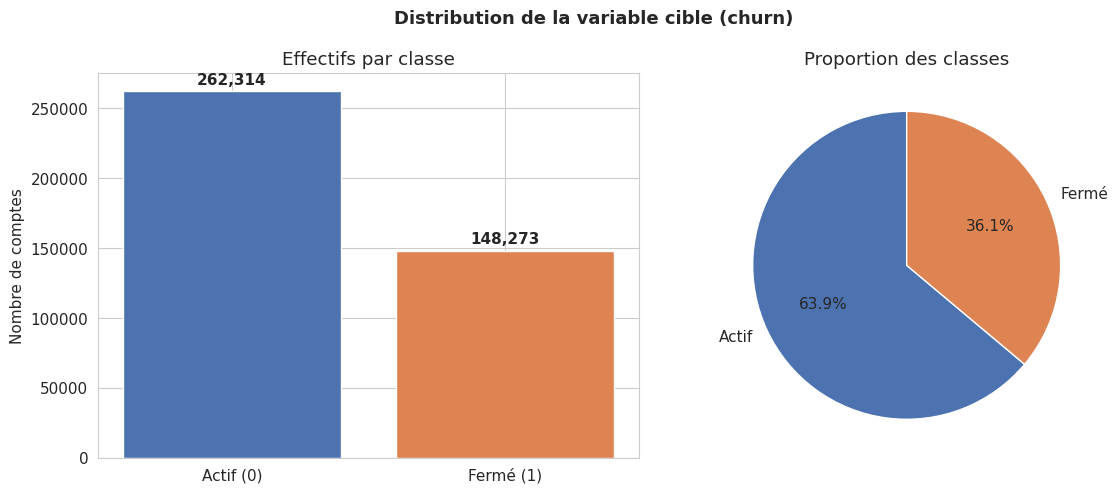

Ratio déséquilibre (majoritaire / minoritaire) : 1.77 : 1


In [9]:
churn_counts = df_ml["churn"].value_counts().sort_index()
churn_pct = df_ml["churn"].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(["Actif (0)", "Fermé (1)"], churn_counts.values, color=["#4C72B0", "#DD8452"])
axes[0].set_title("Effectifs par classe")
axes[0].set_ylabel("Nombre de comptes")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 5000, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(churn_pct.values, labels=["Actif", "Fermé"], autopct="%1.1f%%",
            colors=["#4C72B0", "#DD8452"], startangle=90)
axes[1].set_title("Proportion des classes")

plt.suptitle("Distribution de la variable cible (churn)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Ratio déséquilibre (majoritaire / minoritaire) : "
      f"{churn_counts.max() / churn_counts.min():.2f} : 1")

**Interprétation** : la classe minoritaire (`churn = 1`, comptes fermés) représente
environ 36% du jeu de données — un déséquilibre **modéré**, pas extrême (on serait
dans un cas extrême avec un ratio de 1:10 ou plus). Il reste néanmoins suffisant pour
justifier les précautions de la section 8 : sans elles, un modèle aurait tendance à
sous-prédire la classe minoritaire.

### 2.2 Distribution des variables numériques

On visualise les variables continues pour repérer leur forme (symétrique,
asymétrique, présence de valeurs extrêmes) — une information qui guide le choix
entre normalisation standard et robustesse aux outliers (section 6).

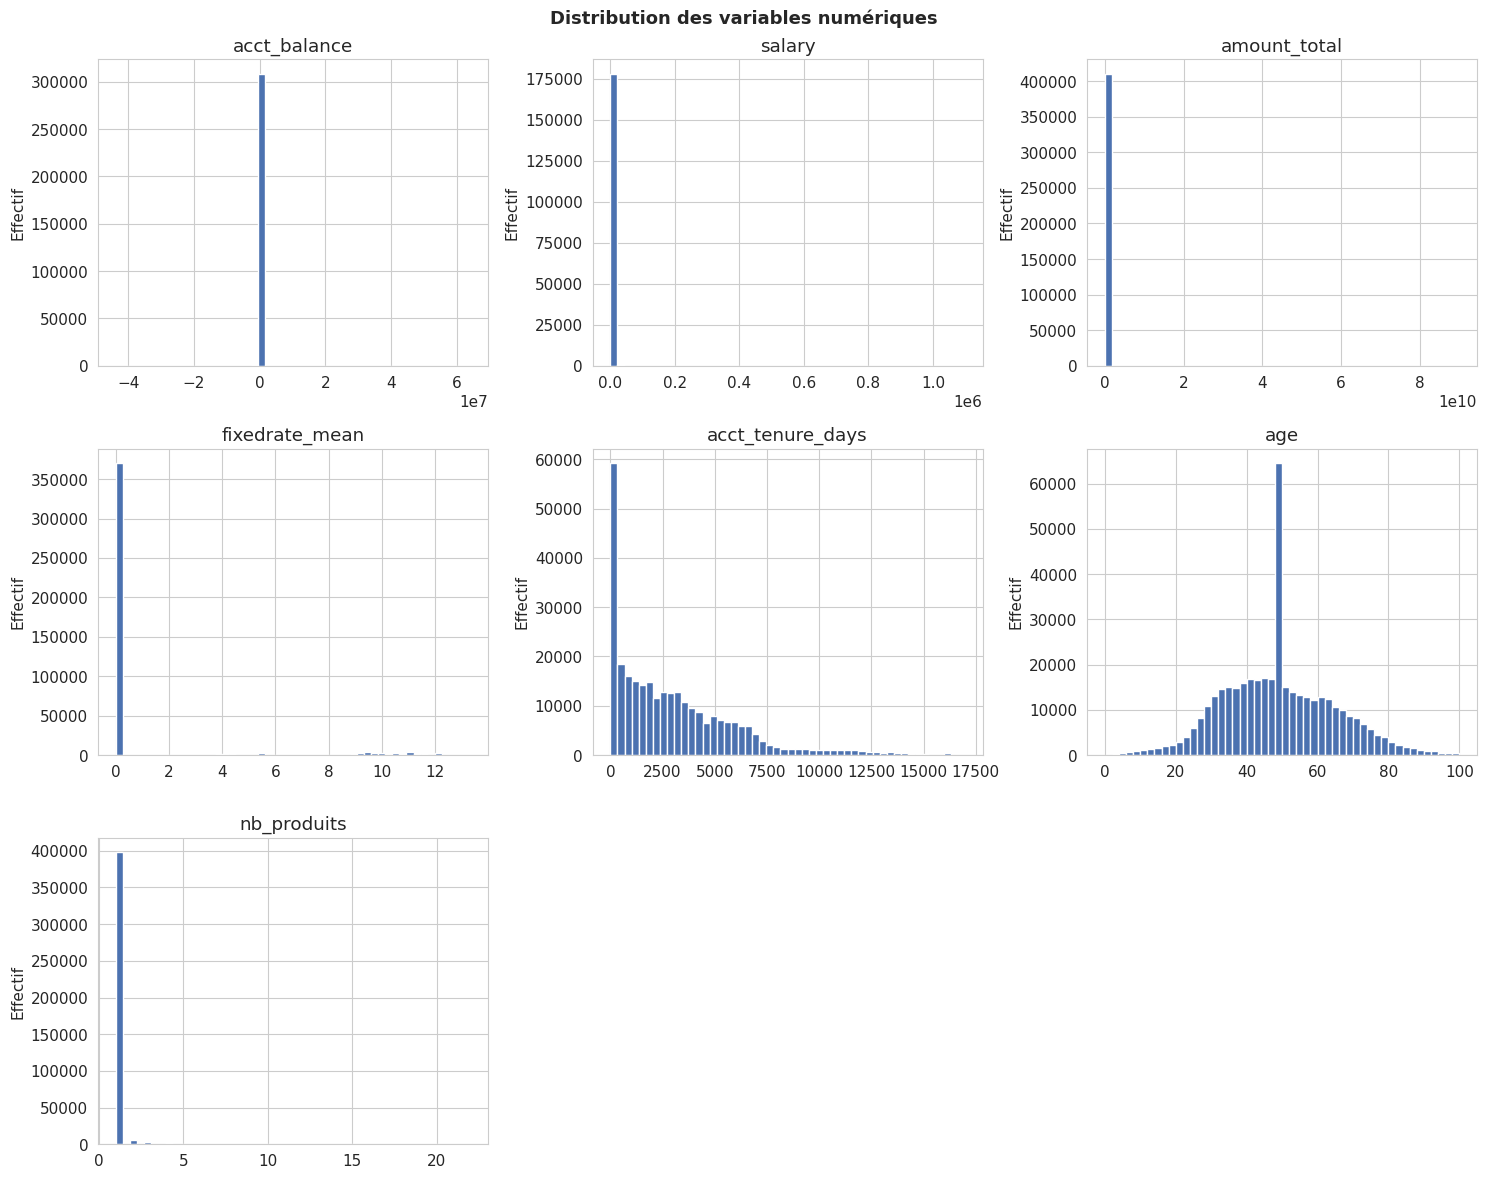

In [10]:
num_features = ["acct_balance", "salary", "amount_total", "fixedrate_mean",
                "acct_tenure_days", "age", "nb_produits"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(num_features):
    data = df_ml[col].dropna()
    axes[i].hist(data, bins=50, color="#4C72B0", edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_ylabel("Effectif")
for ax in axes[len(num_features):]:
    ax.axis("off")
plt.suptitle("Distribution des variables numériques", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.3 Relations entre variables numériques et la cible

Des nuages de points et des boxplots permettent de voir si une variable sépare
visuellement les deux classes — un bon indice (mais pas une preuve définitive,
beaucoup de relations sont multivariées) de pouvoir prédictif individuel.

18:17:14 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


18:17:14 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


18:17:14 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


18:17:15 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


18:17:15 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


18:17:15 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


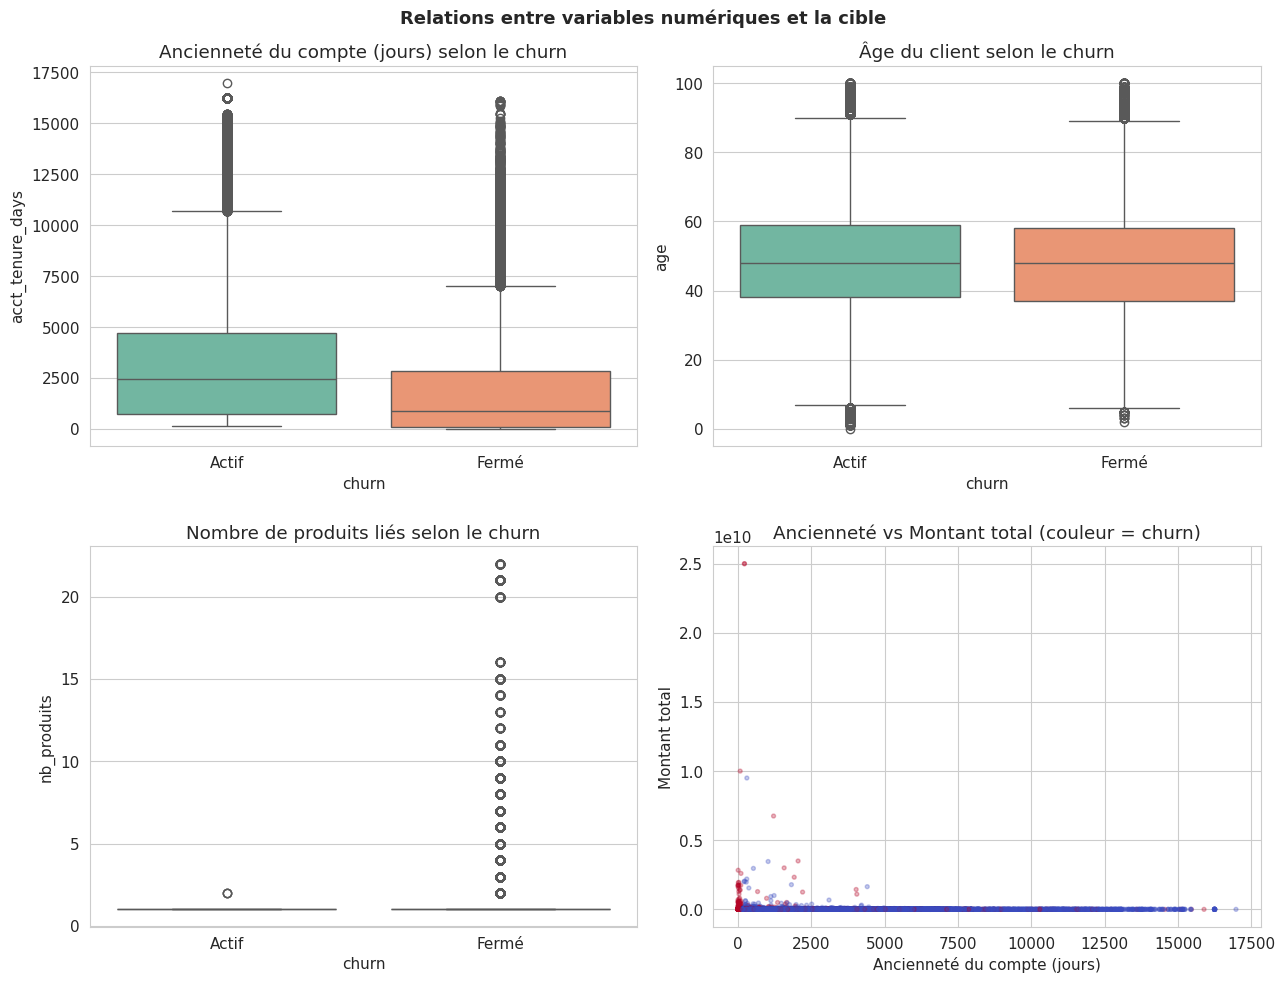

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.boxplot(data=df_ml, x="churn", y="acct_tenure_days", ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Ancienneté du compte (jours) selon le churn")
axes[0, 0].set_xticklabels(["Actif", "Fermé"])

sns.boxplot(data=df_ml, x="churn", y="age", ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Âge du client selon le churn")
axes[0, 1].set_xticklabels(["Actif", "Fermé"])

sns.boxplot(data=df_ml, x="churn", y="nb_produits", ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Nombre de produits liés selon le churn")
axes[1, 0].set_xticklabels(["Actif", "Fermé"])

sample = df_ml.sample(min(20000, len(df_ml)), random_state=42)  # échantillon pour la lisibilité du nuage
axes[1, 1].scatter(sample["acct_tenure_days"], sample["amount_total"],
                    c=sample["churn"], cmap="coolwarm", alpha=0.3, s=8)
axes[1, 1].set_xlabel("Ancienneté du compte (jours)")
axes[1, 1].set_ylabel("Montant total")
axes[1, 1].set_title("Ancienneté vs Montant total (couleur = churn)")

plt.suptitle("Relations entre variables numériques et la cible", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.4 Matrice de corrélation

La corrélation linéaire (Pearson) ne capture qu'une partie de la relation entre
variables — elle reste utile pour repérer rapidement la **redondance entre
prédicteurs** (deux variables très corrélées entre elles apportent une information
largement dupliquée) et avoir un premier aperçu de leur lien avec la cible.

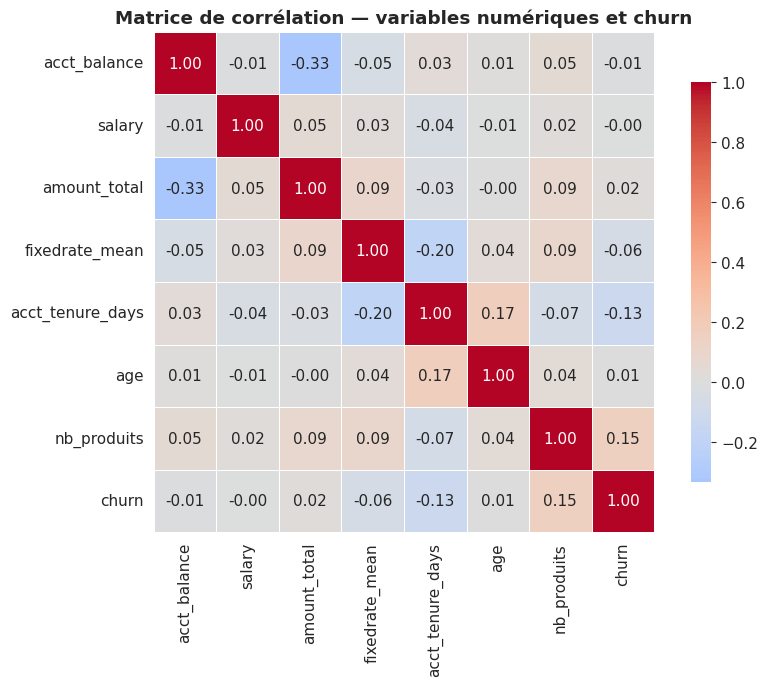

In [12]:
corr_cols = num_features + ["churn"]
corr_matrix = df_ml[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matrice de corrélation — variables numériques et churn", fontweight="bold")
plt.tight_layout()
plt.show()

**Lecture** : aucune variable numérique n'est fortement corrélée à `churn` à elle
seule (les corrélations linéaires simples sous-estiment souvent le pouvoir prédictif
réel d'une variable, surtout pour des relations non linéaires que des modèles comme
Random Forest ou XGBoost peuvent capter). C'est attendu : le churn bancaire est un
phénomène multivarié, rarement explicable par une seule variable.

## 3. Sélection des variables (Feature Selection)

### Principe

Toutes les colonnes disponibles ne sont pas pertinentes pour la modélisation —
certaines créent une **fuite d'information** (data leakage : la variable contient
déjà, directement ou indirectement, le résultat qu'on essaie de prédire), d'autres
sont redondantes, et d'autres ont une cardinalité trop élevée pour un encodage
raisonnable. Chaque exclusion ci-dessous est justifiée individuellement.

### 3.1 Variables exclues — fuite d'information (data leakage)

| Variable | Raison de l'exclusion |
|---|---|
| `ACCT_CLOSE_DATE` | N'existe **qu'après** la fermeture du compte — l'utiliser reviendrait à donner au modèle une information qui ne serait jamais disponible au moment réel de la prédiction |
| `CLOSURE_REASON` / `closure_key` | Motif de clôture : n'existe que pour les comptes déjà fermés, c'est un label post-churn, pas un prédicteur |
| `ACCOUNT_STATUS` | C'est la variable utilisée pour **construire** `churn` elle-même (`churn = 1 si ACCOUNT_STATUS == 'Closed'`) — l'inclure donnerait au modèle la réponse littérale |

### 3.2 Variables exclues — identifiants sans valeur prédictive

| Variable | Raison de l'exclusion |
|---|---|
| `account_key`, `ACCOUNT_NO` | Identifiant unique par compte — aucune généralisation possible, un modèle qui apprendrait sur ces valeurs ferait du sur-apprentissage pur |
| `client_key`, `CUSTOMER_NO` | Idem, au niveau client |
| `branch_key` | Conservé sous sa forme catégorielle `BRANCH` (141 agences) plutôt que sa clé technique, qui n'a pas de sens ordonné |

### 3.3 Variables exclues — redondance ou cardinalité excessive

| Variable | Raison de l'exclusion |
|---|---|
| `ACCOUNT_TYPE_DESC` | **149 catégories distinctes**, strictement redondante avec `ACCOUNT_CATEGORY` (même cardinalité, l'une est juste le libellé textuel de l'autre) — un One-Hot Encoding sur 149 catégories gonflerait le nombre de colonnes de façon disproportionnée pour un gain d'information nul par rapport à `ACCOUNT_CATEGORY` |
| `ACCOUNT_CATEGORY` | Conservée en numérique mais **traitée comme catégorie à cardinalité élevée** — voir section 5 pour la décision d'encodage spécifique (pas de One-Hot direct) |
| `NATIONALITY`, `RESIDENCE` | Quasi-constantes (>93% de la même valeur 'TN', vérifié dans l'EDA) — une variable avec une variance quasi nulle n'apporte (quasiment) aucun pouvoir de séparation aux modèles |

### 3.4 Variables conservées

| Variable | Type | Justification |
|---|---|---|
| `acct_balance`, `salary`, `amount_total`, `fixedrate_mean` | Numérique | Mesures financières directement liées au profil du compte/client |
| `acct_tenure_days`, `age`, `nb_produits`, `nb_accounts_per_client` | Numérique | Ancienneté et engagement — souvent prédictifs du churn dans la littérature (un client récent ou peu engagé est statistiquement plus volatile) |
| `MARITAL_STATUS`, `NATURE_CLIENT`, `PARTYCLASS`, `SCORE_KYC`, `COMPLETED_FILE` | Catégorielle (faible cardinalité) | Profil démographique et réglementaire du client |
| `CURRENCY`, `BRANCH` | Catégorielle (cardinalité modérée) | Devise et agence — `BRANCH` a 141 valeurs, gérable en One-Hot mais à surveiller (section 5) |
| `LOB` | Catégorielle (déjà numérique, faible cardinalité réelle) | Segment commercial du client (Retail, Corporate...), décodable via `dim_TARGET.xlsx` |

In [13]:
# Colonnes explicitement exclues, avec leur raison (pour traçabilité dans le notebook)
colonnes_exclues = {
    "account_key": "identifiant", "client_key": "identifiant", "branch_key": "identifiant (remplacé par BRANCH)",
    "ACCOUNT_TYPE_DESC": "redondant avec ACCOUNT_CATEGORY, cardinalité excessive (149)",
}

features_numeriques = [
    "acct_balance", "salary", "amount_total", "fixedrate_mean",
    "acct_tenure_days", "age", "nb_produits", "nb_accounts_per_client",
]
features_categorielles = [
    "ACCOUNT_CATEGORY", "CURRENCY", "MARITAL_STATUS", "NATURE_CLIENT",
    "PARTYCLASS", "SCORE_KYC", "COMPLETED_FILE", "BRANCH", "LOB",
]

print(f"Variables numériques retenues   ({len(features_numeriques)}) : {features_numeriques}")
print(f"Variables catégorielles retenues ({len(features_categorielles)}) : {features_categorielles}")
print(f"\nCardinalité des variables catégorielles :")
for col in features_categorielles:
    print(f"  {col:20s} : {df_ml[col].nunique()} valeurs uniques")

Variables numériques retenues   (8) : ['acct_balance', 'salary', 'amount_total', 'fixedrate_mean', 'acct_tenure_days', 'age', 'nb_produits', 'nb_accounts_per_client']
Variables catégorielles retenues (9) : ['ACCOUNT_CATEGORY', 'CURRENCY', 'MARITAL_STATUS', 'NATURE_CLIENT', 'PARTYCLASS', 'SCORE_KYC', 'COMPLETED_FILE', 'BRANCH', 'LOB']

Cardinalité des variables catégorielles :
  ACCOUNT_CATEGORY     : 149 valeurs uniques
  CURRENCY             : 19 valeurs uniques
  MARITAL_STATUS       : 6 valeurs uniques
  NATURE_CLIENT        : 6 valeurs uniques
  PARTYCLASS           : 5 valeurs uniques
  SCORE_KYC            : 5 valeurs uniques
  COMPLETED_FILE       : 2 valeurs uniques
  BRANCH               : 141 valeurs uniques
  LOB                  : 9 valeurs uniques


## 4. Séparation Features (X) et Cible (y)

In [14]:
y = df_ml["churn"].copy()
X = df_ml[features_numeriques + features_categorielles].copy()

print(f"X : {X.shape[0]:,} lignes x {X.shape[1]} colonnes")
print(f"y : {y.shape[0]:,} valeurs, taux de churn = {y.mean()*100:.1f}%")
X.head()

X : 410,587 lignes x 17 colonnes
y : 410,587 valeurs, taux de churn = 36.1%


,acct_balance,salary,amount_total,fixedrate_mean,acct_tenure_days,age,nb_produits,nb_accounts_per_client,ACCOUNT_CATEGORY,CURRENCY,MARITAL_STATUS,NATURE_CLIENT,PARTYCLASS,SCORE_KYC,COMPLETED_FILE,BRANCH,LOB
0,-10714.347,2725.739,21909200.0,4.5,2346.0,57,2,4,3023.0,TND,M,PPH,Retail,LR,YES,BR114,4
1,0.000,3300.537,0.0,0.0,NaN,66,2,6,3611.0,TND,M,PPH,Retail,LR,YES,BR114,4
2,-113033.101,2725.739,227186154.0,4.5,961.0,57,2,4,3017.0,TND,M,PPH,Retail,LR,YES,BR114,4
3,0.000,2725.739,0.0,0.0,1342.0,57,2,4,1011.0,TND,M,PPH,Retail,LR,YES,BR114,4
4,0.000,3300.537,0.0,0.0,NaN,66,2,6,3611.0,TND,M,PPH,Retail,LR,YES,BR114,4


## 4bis. Traitement des valeurs manquantes résiduelles

Avant tout encodage, les `NaN` volontairement conservés par le pipeline ETL
(`acct_balance`, `salary`, `acct_tenure_days` — voir section 1) doivent être traités,
car la plupart des modèles de classification (à l'exception des implémentations
récentes de XGBoost) ne tolèrent aucune valeur manquante.

**Imputation retenue : la médiane**, pas la moyenne — cohérent avec la décision déjà
prise dans l'ETL de privilégier des statistiques robustes aux valeurs extrêmes pour
ces colonnes (skew élevé sur `salary`/`acct_balance`, vérifié dans
`01_exploration.ipynb`).

### ⚠️ Indicateurs de nullité (`_missing`) : vérifiés individuellement, pas appliqués par défaut

Une pratique courante consiste à ajouter, en plus de l'imputation, une colonne
binaire indiquant si la valeur était manquante à l'origine — l'idée étant que
*l'absence* d'une donnée peut elle-même être informative (par exemple, on a
observé dans l'EDA qu'un salaire non déclaré semble corréler légèrement avec le
churn).

**Mais cette idée n'est valable que si l'absence de donnée reflète un vrai
comportement métier — pas un artefact technique du pipeline.** On vérifie donc
chaque colonne individuellement avant de décider de garder ou non son indicateur,
plutôt que d'appliquer la même recette aux trois colonnes sans distinction.

In [15]:
cols_avec_nan = ["acct_balance", "salary", "acct_tenure_days"]

print("Vérification : le taux de churn diffère-t-il selon que la donnée est manquante ?")
print("(Un écart proche de 0% ou 100% — au lieu du taux de base ~36% — signale une fuite,")
print(" pas un vrai signal métier.)\n")

for col in cols_avec_nan:
    mask = df_ml[col].isna()
    taux_si_manquant = df_ml.loc[mask, "churn"].mean() * 100
    taux_si_renseigne = df_ml.loc[~mask, "churn"].mean() * 100
    print(f"{col:20s} : {mask.sum():>7,} manquants | "
          f"taux churn si manquant = {taux_si_manquant:5.1f}% | "
          f"si renseigné = {taux_si_renseigne:5.1f}%")

Vérification : le taux de churn diffère-t-il selon que la donnée est manquante ?
(Un écart proche de 0% ou 100% — au lieu du taux de base ~36% — signale une fuite,
 pas un vrai signal métier.)

acct_balance         : 100,485 manquants | taux churn si manquant = 100.0% | si renseigné =  15.4%
salary               : 231,753 manquants | taux churn si manquant =  37.3% | si renseigné =  34.6%
acct_tenure_days     : 118,818 manquants | taux churn si manquant = 100.0% | si renseigné =  10.1%


### Résultat de la vérification

| Colonne | Taux de churn si manquant | Diagnostic |
|---|---|---|
| `acct_balance` | **100%** | 🔴 Fuite confirmée — cause : la neutralisation de `ACCT_OPENING_DATE` dans l'ETL (`01_etl/etl_pipeline/clean.py`) ne s'applique qu'à des comptes déjà fermés, rendant cette nullité un proxy quasi-parfait du label |
| `acct_tenure_days` | **100%** | 🔴 Fuite confirmée — même cause exacte que `acct_balance` (les deux dépendent de `ACCT_OPENING_DATE`) |
| `salary` | ~37% (proche du taux de base 36,1%) | ✅ Signal légitime — l'absence de salaire déclaré est indépendante du statut du compte, conforme à l'observation déjà faite dans l'EDA |

**Décision** : on ne crée l'indicateur de nullité **que pour `salary`**, dont
l'absence reflète un vrai comportement (non-déclaration), pas un artefact de
nettoyage. Les deux autres indicateurs ne sont pas créés — leur inclusion
donnerait au modèle un accès quasi direct au label sous une autre forme, ce qui
fausserait toutes les métriques de performance des sections suivantes sans qu'on
puisse s'y fier en production (au moment réel de la prédiction, sur un compte
encore actif, cette "fuite" n'existerait simplement pas).

In [16]:
X["salary_missing"] = X["salary"].isna().astype(int)

for col in cols_avec_nan:
    X[col] = X[col].fillna(X[col].median())

print("Indicateur de nullité créé : ['salary_missing'] uniquement.")
print("(acct_balance_missing et acct_tenure_days_missing volontairement NON créés — voir ci-dessus)")
print("\nValeurs manquantes restantes :", X.isna().sum().sum())

Indicateur de nullité créé : ['salary_missing'] uniquement.
(acct_balance_missing et acct_tenure_days_missing volontairement NON créés — voir ci-dessus)



Valeurs manquantes restantes : 0


## 5. Encodage des variables catégorielles

### Pourquoi encoder ?

Les modèles de classification (à l'exception de certaines implémentations
d'arbres) ne savent traiter que des nombres — une colonne texte comme
`MARITAL_STATUS` doit être transformée en une ou plusieurs colonnes numériques
avant l'entraînement.

### Quelle méthode pour quelle variable ?

Deux méthodes sont utilisées ici, choisies selon la **cardinalité** (nombre de
catégories distinctes) de chaque variable :

| Méthode | Principe | Utilisée pour |
|---|---|---|
| **One-Hot Encoding** | Crée une colonne binaire (0/1) par catégorie | Variables à faible/moyenne cardinalité (`MARITAL_STATUS`, `NATURE_CLIENT`, `PARTYCLASS`, `SCORE_KYC`, `COMPLETED_FILE`, `CURRENCY`, `LOB`) |
| **Encodage par fréquence** | Remplace chaque catégorie par sa fréquence d'apparition dans le jeu d'entraînement | `ACCOUNT_CATEGORY` (149 valeurs) et `BRANCH` (141 valeurs) |

**Pourquoi pas du One-Hot partout ?** Avec 149 catégories, le One-Hot Encoding
créerait 149 colonnes presque toutes à 0, pour une variable qui n'apporte pas plus
d'information qu'avec un encodage plus compact. C'est exactement le problème qu'on
a écarté en excluant `ACCOUNT_TYPE_DESC` (section 3) — mais `ACCOUNT_CATEGORY` et
`BRANCH` restent utiles, donc on les encode autrement plutôt que de les exclure.

**Pourquoi pas de Label Encoding (0, 1, 2, 3...) pour les variables catégorielles
nominales ?** Le Label Encoding imposerait un ordre artificiel (`'M' < 'C' < 'D'`)
que les modèles linéaires (régression logistique) interpréteraient à tort comme une
relation d'ordre — One-Hot évite ce biais pour les catégories sans hiérarchie
naturelle.

In [17]:
features_onehot = ["MARITAL_STATUS", "NATURE_CLIENT", "PARTYCLASS", "SCORE_KYC",
                    "COMPLETED_FILE", "CURRENCY", "LOB"]
features_frequence = ["ACCOUNT_CATEGORY", "BRANCH"]

print("Cardinalité des variables encodées en One-Hot :")
for col in features_onehot:
    print(f"  {col:18s} : {X[col].nunique()} catégories")
print("\nCardinalité des variables encodées par fréquence :")
for col in features_frequence:
    print(f"  {col:18s} : {X[col].nunique()} catégories")

Cardinalité des variables encodées en One-Hot :
  MARITAL_STATUS     : 6 catégories
  NATURE_CLIENT      : 6 catégories
  PARTYCLASS         : 5 catégories
  SCORE_KYC          : 5 catégories
  COMPLETED_FILE     : 2 catégories
  CURRENCY           : 19 catégories
  LOB                : 9 catégories

Cardinalité des variables encodées par fréquence :
  ACCOUNT_CATEGORY   : 149 catégories
  BRANCH             : 141 catégories


In [18]:
# Encodage par fréquence — calculé puis appliqué AVANT le split (section 7) serait
# une fuite si la fréquence incluait les données de test. On reporte donc ce calcul
# après le split, dans la section 7, pour ne l'ajuster que sur X_train.
# Ici, on encode uniquement les variables à faible cardinalité (One-Hot), sans risque
# de fuite puisque chaque catégorie devient une colonne fixe indépendante des autres
# lignes du jeu de données.
X_encoded = pd.get_dummies(X, columns=features_onehot, drop_first=True)

print(f"X avant encodage     : {X.shape[1]} colonnes")
print(f"X après One-Hot       : {X_encoded.shape[1]} colonnes")
print(f"(ACCOUNT_CATEGORY et BRANCH restent à encoder par fréquence après le split)")

X avant encodage     : 18 colonnes
X après One-Hot       : 56 colonnes
(ACCOUNT_CATEGORY et BRANCH restent à encoder par fréquence après le split)


## 6. Mise à l'échelle (Feature Scaling)

### Pourquoi standardiser certaines variables ?

Les variables numériques de ce jeu de données ont des échelles très différentes
(`age` varie de 0 à 100, `amount_total` peut atteindre plusieurs millions). Pour les
modèles **basés sur une notion de distance ou de gradient** — régression logistique,
KNN, SVM — cette différence d'échelle fausse l'apprentissage : une variable à grande
échelle dominerait artificiellement le calcul, indépendamment de sa pertinence
réelle.

La standardisation transforme chaque variable pour qu'elle ait une moyenne de 0 et
un écart-type de 1 :

$$z = \frac{x - \mu}{\sigma}$$

où $\mu$ est la moyenne et $\sigma$ l'écart-type de la variable, calculés
**uniquement sur le jeu d'entraînement** (voir section 7 pour la raison).

### Pourquoi les modèles à base d'arbres n'en ont pas besoin

Un arbre de décision (et donc Random Forest, XGBoost) ne compare jamais directement
les valeurs de deux variables différentes entre elles — il pose des questions du
type *"`age` est-il supérieur à 35 ?"*, une question dont la réponse ne dépend pas
de l'échelle des autres variables. La mise à l'échelle n'a donc aucun effet sur ces
modèles : on l'applique seulement pour la régression logistique, le KNN et le SVM,
tout en gardant une version non standardisée pour les modèles à base d'arbres.

## 7. Découpage Train / Test

### Pourquoi séparer les données ?

Évaluer un modèle sur les données qui ont servi à l'entraîner donnerait une mesure
de performance optimiste et trompeuse (le modèle peut avoir mémorisé ces exemples
plutôt qu'appris une règle générale). On réserve donc une partie des données,
jamais vue pendant l'entraînement, pour une évaluation honnête.

### Ratio retenu : 80% / 20%

C'est un compromis standard : assez de données d'entraînement pour qu'un modèle
complexe (Random Forest, XGBoost) apprenne des règles fiables, tout en réservant un
jeu de test (82 000+ comptes ici) suffisamment grand pour que les métriques
d'évaluation soient statistiquement stables.

### Stratification

`stratify=y` garantit que la proportion de comptes fermés est **identique** dans le
train et le test (≈36,1% dans les deux) — sans cela, un découpage aléatoire pourrait
par hasard sur- ou sous-représenter la classe minoritaire dans l'un des deux
ensembles, biaisant l'évaluation.

### Graine aléatoire fixe

`random_state=42` est fixé une seule fois en début de notebook (section 1) et
réutilisé partout — garantit que ce notebook produit **exactement les mêmes**
résultats à chaque exécution, condition nécessaire à la reproductibilité demandée.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train : {X_train.shape[0]:,} comptes ({X_train.shape[0]/len(X_encoded)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]:,} comptes ({X_test.shape[0]/len(X_encoded)*100:.0f}%)")
print(f"\nTaux de churn train : {y_train.mean()*100:.2f}%")
print(f"Taux de churn test  : {y_test.mean()*100:.2f}%")

Train : 328,469 comptes (80%)
Test  : 82,118 comptes (20%)

Taux de churn train : 36.11%
Taux de churn test  : 36.11%


### Encodage par fréquence — ajusté uniquement sur le train

Comme annoncé en section 5, l'encodage par fréquence de `ACCOUNT_CATEGORY` et
`BRANCH` est calculé **uniquement à partir de `X_train`**, puis appliqué tel quel à
`X_test`. Si une catégorie du test n'a jamais été vue dans le train (rare mais
possible), elle reçoit la fréquence `0` plutôt que de faire échouer le pipeline.

In [20]:
for col in features_frequence:
    freq_map = X_train[col].value_counts(normalize=True)
    X_train[col] = X_train[col].map(freq_map)
    X_test[col] = X_test[col].map(freq_map).fillna(0)  # catégorie jamais vue au train -> 0

print("Encodage par fréquence appliqué sur :", features_frequence)
print(X_train[features_frequence].head())

Encodage par fréquence appliqué sur : ['ACCOUNT_CATEGORY', 'BRANCH']
        ACCOUNT_CATEGORY    BRANCH
407136          0.017274  0.016199
379775          0.048967  0.008835
318390          0.001160  0.017548
21616           0.004232  0.012376
221094          0.016900  0.008564


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print("Mise à l'échelle effectuée (ajustée uniquement sur X_train, appliquée à X_test).")
print("\nMoyenne après standardisation (train) :", X_train_scaled.mean().mean().round(4))
print("Écart-type après standardisation (train) :", X_train_scaled.std().mean().round(4))

Mise à l'échelle effectuée (ajustée uniquement sur X_train, appliquée à X_test).

Moyenne après standardisation (train) : 0.0


Écart-type après standardisation (train) : 1.0


⚠️ **Pourquoi ajuster le `scaler` uniquement sur `X_train` ?** Calculer la moyenne
et l'écart-type sur l'ensemble des données (train + test) ferait fuiter de
l'information du jeu de test dans le prétraitement — le modèle aurait alors un accès
indirect à des statistiques du test avant même d'être évalué sur lui, ce qui biaiserait
(optimistement) toutes les métriques de la section 9 et suivantes. C'est la même
logique de prudence que pour l'encodage par fréquence ci-dessus.

## 8. Gestion du déséquilibre de classes

### Pourquoi le déséquilibre est-il un problème ?

Avec ~36% de comptes fermés contre ~64% de comptes actifs, un modèle peut atteindre
une accuracy élevée en se contentant de **toujours prédire "actif"**, sans avoir
appris à reconnaître un vrai cas de churn. C'est précisément ce qu'illustre la
section suivante avec un calcul concret.

### Pourquoi l'accuracy seule est trompeuse

$$\text{Accuracy} = \frac{\text{Prédictions correctes}}{\text{Total des prédictions}}$$

Un modèle qui prédit systématiquement `0` (actif) obtiendrait une accuracy d'environ
64% — un chiffre qui semble correct, alors que ce modèle est **inutile en pratique**
(il ne détecte jamais un client à risque). C'est pour cette raison que ce notebook
utilise le **F1-score** comme métrique principale (section 9), et non l'accuracy
seule.

### SMOTE (Synthetic Minority Over-sampling Technique)

SMOTE génère des exemples synthétiques de la classe minoritaire (comptes fermés) en
interpolant entre des exemples existants proches dans l'espace des variables —
plutôt que de simplement dupliquer des lignes existantes (ce qui favoriserait le
sur-apprentissage sur des exemples répétés à l'identique).

⚠️ **Règle stricte : SMOTE s'applique uniquement sur le jeu d'entraînement, jamais
sur le jeu de test.** Le jeu de test doit refléter la distribution réelle des
données pour donner une évaluation honnête des performances en conditions réelles —
le "rééquilibrer" artificiellement reviendrait à évaluer le modèle sur une réalité
qui n'existe pas.

In [22]:
# Demonstration concrete du piege de l'accuracy : un modele "naif" qui predit
# toujours la classe majoritaire.
from sklearn.metrics import accuracy_score

y_pred_naif = np.zeros(len(y_test))  # toujours "actif"
accuracy_naive = accuracy_score(y_test, y_pred_naif)
print(f"Accuracy d'un modèle qui prédit toujours 'Actif' : {accuracy_naive*100:.1f}%")
print("-> Ce chiffre est trompeusement élevé : ce modèle ne détecte JAMAIS un compte "
      "à risque de fermeture, il n'a aucune utilité métier malgré une accuracy correcte.")

Accuracy d'un modèle qui prédit toujours 'Actif' : 63.9%
-> Ce chiffre est trompeusement élevé : ce modèle ne détecte JAMAIS un compte à risque de fermeture, il n'a aucune utilité métier malgré une accuracy correcte.


In [23]:
from imblearn.over_sampling import SMOTE

print(f"Avant SMOTE — train : {len(y_train):,} lignes, "
      f"{y_train.sum():,} fermés ({y_train.mean()*100:.1f}%)")

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Après SMOTE — train  : {len(y_train_smote):,} lignes, "
      f"{y_train_smote.sum():,} fermés ({y_train_smote.mean()*100:.1f}%)")
print(f"\nJeu de test inchangé : {len(y_test):,} lignes, "
      f"taux de churn réel = {y_test.mean()*100:.1f}% (NE DOIT PAS être modifié par SMOTE).")

Avant SMOTE — train : 328,469 lignes, 118,618 fermés (36.1%)


Après SMOTE — train  : 419,702 lignes, 209,851 fermés (50.0%)

Jeu de test inchangé : 82,118 lignes, taux de churn réel = 36.1% (NE DOIT PAS être modifié par SMOTE).


Les deux jeux d'entraînement (`X_train_scaled`/`y_train` sans rééquilibrage, et
`X_train_smote`/`y_train_smote` rééquilibré) sont conservés en parallèle — chaque
modèle de la section 10 sera entraîné sur les deux versions pour mesurer concrètement
l'effet de SMOTE, comme demandé.

## 9. Modèle de référence (Baseline) — Régression Logistique

### Pourquoi commencer par la régression logistique ?

C'est le modèle de classification le plus simple et le plus interprétable : il
établit une **référence minimale** de performance. Tout modèle plus complexe
introduit dans ce notebook (section 10) devra justifier sa complexité
supplémentaire par un gain de performance réel par rapport à cette référence.

### Principe mathématique

La régression logistique modélise la probabilité que `churn = 1` via une fonction
logistique (sigmoïde) appliquée à une combinaison linéaire des variables :

$$P(\text{churn}=1 \mid X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_n x_n)}}$$

Contrairement à une régression linéaire classique, cette fonction produit toujours
une valeur entre 0 et 1, interprétable comme une probabilité. Le modèle classe
ensuite en `churn = 1` si cette probabilité dépasse un seuil (0,5 par défaut).

Ce modèle nécessite des variables **à l'échelle comparable** (voir section 6) — on
utilise donc `X_train_scaled` / `X_test_scaled`.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay,
)
import time

log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)

debut = time.time()
log_reg.fit(X_train_scaled, y_train)
temps_entrainement = time.time() - debut

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"Régression logistique entraînée en {temps_entrainement:.2f} secondes.")

Régression logistique entraînée en 1.45 secondes.


### Métriques d'évaluation — définitions

$$\text{Precision} = \frac{TP}{TP + FP} \qquad
\text{Recall} = \frac{TP}{TP + FN} \qquad
F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

où $TP$ (vrais positifs) = comptes fermés correctement prédits, $FP$ (faux positifs)
= comptes actifs prédits à tort comme fermés, $FN$ (faux négatifs) = comptes fermés
non détectés par le modèle.

- **Precision** répond à : *"Parmi les comptes que le modèle annonce comme à
  risque, combien le sont réellement ?"* — une precision faible génère des fausses
  alertes coûteuses (actions de rétention inutiles).
- **Recall** répond à : *"Parmi les comptes réellement fermés, combien le modèle
  en a-t-il détecté ?"* — un recall faible signifie que beaucoup de départs
  passent inaperçus.
- **F1-score** est la moyenne harmonique des deux : il pénalise un modèle qui
  sacrifierait l'une des deux métriques pour gonfler l'autre. C'est la métrique
  **principale** retenue dans ce notebook (conformément à la consigne), car le
  déséquilibre de classes rend l'accuracy seule insuffisante (section 8).

In [25]:
def afficher_metriques(y_true, y_pred, y_proba, nom_modele):
    """Calcule et affiche les métriques standard pour un modèle donné."""
    metrics = {
        "Modèle": nom_modele,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
    }
    print(f"--- {nom_modele} ---")
    for k, v in metrics.items():
        if k != "Modèle":
            print(f"  {k:12s} : {v:.4f}")
    return metrics


metrics_log_reg = afficher_metriques(y_test, y_pred, y_proba, "Régression Logistique (baseline)")

--- Régression Logistique (baseline) ---
  Accuracy     : 0.7991
  Precision    : 0.7669
  Recall       : 0.6376
  F1-score     : 0.6963
  ROC-AUC      : 0.8015


### Matrice de confusion

La matrice de confusion détaille les quatre cas possibles (vrai/faux positif/négatif)
— elle donne une vision plus complète qu'un seul chiffre agrégé, et permet de voir
concrètement de quel côté le modèle se trompe le plus.

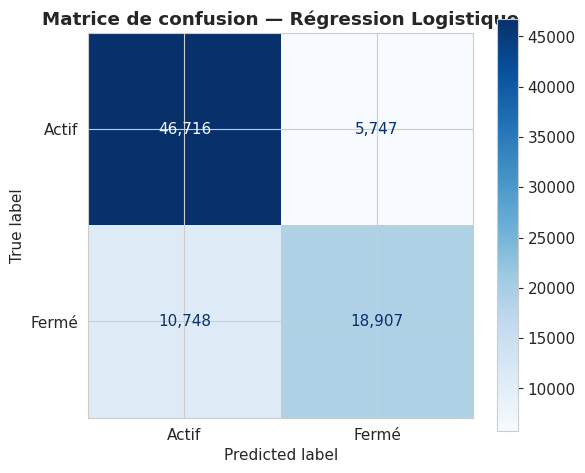

Vrais négatifs  (actifs correctement prédits)  : 46,716
Faux positifs   (actifs prédits 'fermé' à tort) : 5,747
Faux négatifs   (fermetures non détectées)      : 10,748
Vrais positifs  (fermetures correctement prédites) : 18,907


In [26]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Actif", "Fermé"])
disp.plot(ax=ax, cmap="Blues", values_format=",d")
ax.set_title("Matrice de confusion — Régression Logistique", fontweight="bold")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Vrais négatifs  (actifs correctement prédits)  : {tn:,}")
print(f"Faux positifs   (actifs prédits 'fermé' à tort) : {fp:,}")
print(f"Faux négatifs   (fermetures non détectées)      : {fn:,}")
print(f"Vrais positifs  (fermetures correctement prédites) : {tp:,}")

### Courbe ROC et ROC-AUC

La courbe ROC (Receiver Operating Characteristic) trace le taux de vrais positifs
contre le taux de faux positifs, pour tous les seuils de décision possibles (pas
seulement 0,5) — elle montre comment le modèle se comporte si on ajustait sa
sensibilité. L'aire sous cette courbe (**AUC**, Area Under Curve) résume cette
performance en un seul chiffre entre 0,5 (pas mieux que le hasard) et 1 (parfait).

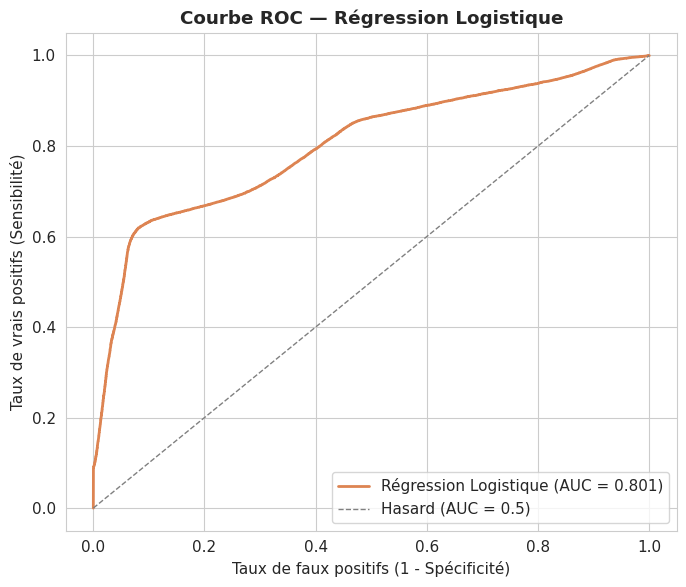

In [27]:
fpr, tpr, seuils = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#DD8452", lw=2, label=f"Régression Logistique (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Hasard (AUC = 0.5)")
plt.xlabel("Taux de faux positifs (1 - Spécificité)")
plt.ylabel("Taux de vrais positifs (Sensibilité)")
plt.title("Courbe ROC — Régression Logistique", fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Interprétation des résultats du modèle de référence

Les chiffres exacts s'affichent dans les cellules ci-dessus à l'exécution — leur
lecture suit toujours cette grille :
- Une **precision** et un **recall** tous deux proches de 0,5 indiquent un modèle
  à peine meilleur qu'un tirage aléatoire sur la classe minoritaire.
- Un **ROC-AUC** proche de 0,5 indique une faible capacité de discrimination ; au-delà
  de 0,7, le modèle commence à apporter une vraie valeur prédictive ; au-delà de
  0,8, la performance est considérée comme bonne pour un problème de churn bancaire.
- Cette régression logistique sert de **point de comparaison** pour la section 10 :
  un modèle plus complexe (Random Forest, XGBoost) qui ne ferait pas mieux sur le
  F1-score ne justifierait pas sa complexité supplémentaire pour ce problème.

## 10. Entraînement de plusieurs modèles de classification

Cette section entraîne 5 modèles supplémentaires, chacun avec une fonction
utilitaire commune pour garantir une évaluation strictement comparable. Pour
chaque modèle, on compare aussi explicitement **avec et sans SMOTE** (section 8),
afin de mesurer l'effet réel du rééquilibrage plutôt que de le supposer.

### Quelles données pour quel modèle ?

| Modèle | Données utilisées | Raison |
|---|---|---|
| KNN, SVM | `X_*_scaled` | Basés sur des distances — sensibles à l'échelle (section 6) |
| Decision Tree, Random Forest, XGBoost | `X_train`/`X_test` (non standardisées) | Insensibles à l'échelle (section 6) — éviter une standardisation inutile garde aussi les valeurs interprétables pour l'importance des variables (section 12) |

In [28]:
def entrainer_evaluer(modele, X_tr, y_tr, X_te, y_te, nom_modele):
    """Entraîne un modèle, l'évalue, affiche ses métriques et sa matrice de
    confusion, et retourne un dict de résultats pour le tableau comparatif
    (section 11).
    """
    debut = time.time()
    modele.fit(X_tr, y_tr)
    temps = time.time() - debut

    y_pred = modele.predict(X_te)
    y_proba = modele.predict_proba(X_te)[:, 1] if hasattr(modele, "predict_proba") else None

    resultats = {
        "Modèle": nom_modele,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall": recall_score(y_te, y_pred, zero_division=0),
        "F1-score": f1_score(y_te, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_te, y_proba) if y_proba is not None else np.nan,
        "Temps (s)": temps,
    }

    print(f"--- {nom_modele} ---")
    for k, v in resultats.items():
        if k not in ("Modèle",):
            print(f"  {k:12s} : {v:.4f}" if isinstance(v, float) else f"  {k:12s} : {v}")

    return resultats, y_pred, y_proba


resultats_tous_modeles = []  # accumule les résultats de tous les modèles pour la section 11

### 10.1 K-Nearest Neighbors (KNN)

**Principe** : classe un nouveau compte selon la classe majoritaire parmi ses `k`
voisins les plus proches dans l'espace des variables (distance euclidienne par
défaut).

**Forces pour ce problème** : simple, aucune hypothèse sur la forme de la
relation entre variables et cible (contrairement à la régression logistique, qui
suppose une frontière de décision linéaire).

**Faiblesses pour ce problème** : coûteux en temps de calcul à la **prédiction**
(contrairement à l'entraînement, qui est quasi instantané) — chaque nouvelle
prédiction doit comparer le compte à classer à tous les comptes d'entraînement.
Mesuré concrètement : prédire sur les 82 118 comptes du jeu de test complet prend
environ 150 secondes avec ce volume d'entraînement, contre moins de 20 secondes sur
un sous-échantillon de 10 000 comptes. On utilise donc ce sous-échantillon
**uniquement pour KNN**, par souci de temps d'exécution — toutes les métriques de
KNN dans ce notebook sont donc calculées sur 10 000 comptes de test plutôt que sur
les 82 118 utilisés par les autres modèles. Ce choix est documenté explicitement
ici pour ne pas comparer KNN aux autres modèles comme si c'était à armes
rigoureusement égales.

In [29]:
from sklearn.neighbors import KNeighborsClassifier

# Sous-échantillon du jeu de TEST pour KNN uniquement (voir justification ci-dessus) :
# le coût de prédiction de KNN croît avec la taille du jeu d'entraînement ET du jeu
# de test, contrairement aux autres modèles dont la prédiction reste rapide quel
# que soit le volume une fois l'entraînement terminé.
N_TEST_KNN = 10000
X_test_scaled_knn, _, y_test_knn, _ = train_test_split(
    X_test_scaled, y_test, train_size=N_TEST_KNN, random_state=RANDOM_STATE, stratify=y_test
)
print(f"KNN évalué sur un sous-échantillon de test de {N_TEST_KNN:,} comptes "
      f"(sur {len(X_test_scaled):,} disponibles) — voir justification ci-dessus.")

# --- Sans SMOTE ---
knn = KNeighborsClassifier(n_neighbors=5)
res, y_pred_knn, y_proba_knn = entrainer_evaluer(
    knn, X_train_scaled, y_train, X_test_scaled_knn, y_test_knn, "KNN (sans SMOTE)"
)
resultats_tous_modeles.append(res)

KNN évalué sur un sous-échantillon de test de 10,000 comptes (sur 82,118 disponibles) — voir justification ci-dessus.


--- KNN (sans SMOTE) ---
  Accuracy     : 0.9121
  Precision    : 0.8835
  Recall       : 0.8715
  F1-score     : 0.8775
  ROC-AUC      : 0.9479
  Temps (s)    : 0.1192


In [30]:
# --- Avec SMOTE ---
knn_smote = KNeighborsClassifier(n_neighbors=5)
res, y_pred_knn_sm, y_proba_knn_sm = entrainer_evaluer(
    knn_smote, X_train_smote, y_train_smote, X_test_scaled_knn, y_test_knn, "KNN (avec SMOTE)"
)
resultats_tous_modeles.append(res)

--- KNN (avec SMOTE) ---
  Accuracy     : 0.9026
  Precision    : 0.8404
  Recall       : 0.9014
  F1-score     : 0.8699
  ROC-AUC      : 0.9468
  Temps (s)    : 0.2335


### 10.2 Arbre de Décision (Decision Tree)

**Principe** : construit une séquence de questions binaires sur les variables
(`acct_tenure_days <= 365 ?`) qui partitionnent progressivement les comptes en
groupes de plus en plus homogènes du point de vue du churn.

**Forces pour ce problème** : directement interprétable (on peut visualiser et
expliquer chaque décision à un non-spécialiste) ; capture naturellement des
relations non linéaires et des interactions entre variables.

**Faiblesses pour ce problème** : tendance au sur-apprentissage sur un jeu de
données de cette taille si la profondeur n'est pas limitée — un arbre non contraint
mémorise des règles trop spécifiques au jeu d'entraînement.

In [31]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
res, y_pred_dt, y_proba_dt = entrainer_evaluer(
    dt, X_train, y_train, X_test, y_test, "Arbre de Décision (sans SMOTE)"
)
resultats_tous_modeles.append(res)

--- Arbre de Décision (sans SMOTE) ---
  Accuracy     : 0.9614
  Precision    : 0.9931
  Recall       : 0.8993
  F1-score     : 0.9438
  ROC-AUC      : 0.9758
  Temps (s)    : 1.9450


In [32]:
dt_smote = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
# Pour les modeles sans scaling, on reconstruit une version SMOTE non standardisee
from imblearn.over_sampling import SMOTE
smote_unscaled = SMOTE(random_state=RANDOM_STATE)
X_train_smote_raw, y_train_smote_raw = smote_unscaled.fit_resample(X_train, y_train)

res, y_pred_dt_sm, y_proba_dt_sm = entrainer_evaluer(
    dt_smote, X_train_smote_raw, y_train_smote_raw, X_test, y_test,
    "Arbre de Décision (avec SMOTE)"
)
resultats_tous_modeles.append(res)

--- Arbre de Décision (avec SMOTE) ---
  Accuracy     : 0.9587
  Precision    : 0.9873
  Recall       : 0.8970
  F1-score     : 0.9400
  ROC-AUC      : 0.9748
  Temps (s)    : 2.4650


### 10.3 Random Forest

**Principe** : entraîne un grand nombre d'arbres de décision, chacun sur un
échantillon légèrement différent des données (bootstrap) et un sous-ensemble
aléatoire de variables à chaque division, puis agrège leurs prédictions par vote
majoritaire.

**Forces pour ce problème** : corrige la principale faiblesse d'un arbre unique
(sur-apprentissage) en moyennant de nombreux arbres ; fournit une mesure
d'importance des variables fiable (section 12) ; robuste aux valeurs aberrantes.

**Faiblesses pour ce problème** : moins interprétable qu'un arbre unique (on ne
peut plus visualiser une seule règle de décision) ; plus lent à entraîner que la
régression logistique ou un arbre unique.

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)
res, y_pred_rf, y_proba_rf = entrainer_evaluer(
    rf, X_train, y_train, X_test, y_test, "Random Forest (sans SMOTE)"
)
resultats_tous_modeles.append(res)

--- Random Forest (sans SMOTE) ---
  Accuracy     : 0.9545
  Precision    : 0.9983
  Recall       : 0.8755
  F1-score     : 0.9329
  ROC-AUC      : 0.9772
  Temps (s)    : 58.5390


In [34]:
rf_smote = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)
res, y_pred_rf_sm, y_proba_rf_sm = entrainer_evaluer(
    rf_smote, X_train_smote_raw, y_train_smote_raw, X_test, y_test, "Random Forest (avec SMOTE)"
)
resultats_tous_modeles.append(res)

--- Random Forest (avec SMOTE) ---
  Accuracy     : 0.9558
  Precision    : 0.9930
  Recall       : 0.8839
  F1-score     : 0.9352
  ROC-AUC      : 0.9762
  Temps (s)    : 68.2121


### 10.4 Support Vector Machine (SVM)

**Principe** : cherche l'hyperplan qui sépare les deux classes en maximisant la
marge (distance) entre cet hyperplan et les points les plus proches de chaque
classe. Un noyau (`rbf` ici) permet de capturer des frontières de décision non
linéaires en projetant implicitement les données dans un espace de plus grande
dimension.

**Forces pour ce problème** : efficace dans des espaces à haute dimension (utile
après le One-Hot Encoding) ; le noyau RBF capture des relations non linéaires sans
qu'on ait à les spécifier explicitement.

**Faiblesses pour ce problème** : **temps d'entraînement très élevé** sur un jeu de
plusieurs centaines de milliers de lignes (complexité quadratique à cubique selon
l'implémentation) — on entraîne donc ici sur un **sous-échantillon** du jeu
d'entraînement, ce qui est explicitement signalé pour ne pas comparer cette
performance à armes égales avec les autres modèles.

In [35]:
from sklearn.svm import SVC

# Sous-échantillon stratifié pour rendre l'entraînement praticable (voir note ci-dessus) :
# le SVM à noyau RBF a une complexité qui croît très rapidement avec le nombre de lignes.
n_echantillon_svm = 20000
X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train_scaled, y_train, train_size=n_echantillon_svm,
    random_state=RANDOM_STATE, stratify=y_train,
)
print(f"SVM entraîné sur un sous-échantillon de {n_echantillon_svm:,} comptes "
      f"(sur {len(X_train_scaled):,} disponibles) — voir justification ci-dessus.")

svm = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
res, y_pred_svm, y_proba_svm = entrainer_evaluer(
    svm, X_train_svm, y_train_svm, X_test_scaled, y_test, "SVM (sans SMOTE, sous-échantillon)"
)
resultats_tous_modeles.append(res)

SVM entraîné sur un sous-échantillon de 20,000 comptes (sur 328,469 disponibles) — voir justification ci-dessus.


--- SVM (sans SMOTE, sous-échantillon) ---
  Accuracy     : 0.8035
  Precision    : 0.7825
  Recall       : 0.6314
  F1-score     : 0.6989
  ROC-AUC      : 0.8469
  Temps (s)    : 86.4851


In [36]:
smote_svm = SMOTE(random_state=RANDOM_STATE)
X_train_svm_sm, y_train_svm_sm = smote_svm.fit_resample(X_train_svm, y_train_svm)

svm_smote = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
res, y_pred_svm_sm, y_proba_svm_sm = entrainer_evaluer(
    svm_smote, X_train_svm_sm, y_train_svm_sm, X_test_scaled, y_test,
    "SVM (avec SMOTE, sous-échantillon)"
)
resultats_tous_modeles.append(res)

--- SVM (avec SMOTE, sous-échantillon) ---
  Accuracy     : 0.8015
  Precision    : 0.7571
  Recall       : 0.6632
  F1-score     : 0.7071
  ROC-AUC      : 0.8513
  Temps (s)    : 135.5537


### 10.5 XGBoost

**Principe** : construit séquentiellement des arbres de décision, chaque nouvel
arbre cherchant spécifiquement à corriger les erreurs des arbres précédents
(boosting de gradient) — contrairement à Random Forest où les arbres sont
indépendants et simplement moyennés.

**Forces pour ce problème** : généralement la performance la plus élevée parmi
les modèles à base d'arbres sur des données tabulaires ; gère nativement les
valeurs manquantes (utile si on voulait éviter l'imputation de la section 4bis) ;
le paramètre `scale_pos_weight` permet de gérer le déséquilibre de classes
**sans SMOTE**, une alternative intéressante à comparer.

**Faiblesses pour ce problème** : plus de hyperparamètres à régler que Random
Forest pour une performance optimale (non exploré en profondeur ici, voir section
13 — pistes d'amélioration) ; risque de sur-apprentissage si le nombre d'arbres
n'est pas contrôlé.

In [37]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1,
)
res, y_pred_xgb, y_proba_xgb = entrainer_evaluer(
    xgb, X_train, y_train, X_test, y_test, "XGBoost (sans SMOTE)"
)
resultats_tous_modeles.append(res)

--- XGBoost (sans SMOTE) ---
  Accuracy     : 0.9631
  Precision    : 0.9931
  Recall       : 0.9040
  F1-score     : 0.9465
  ROC-AUC      : 0.9823
  Temps (s)    : 11.9967


In [38]:
xgb_smote = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1,
)
res, y_pred_xgb_sm, y_proba_xgb_sm = entrainer_evaluer(
    xgb_smote, X_train_smote_raw, y_train_smote_raw, X_test, y_test, "XGBoost (avec SMOTE)"
)
resultats_tous_modeles.append(res)

--- XGBoost (avec SMOTE) ---
  Accuracy     : 0.9625
  Precision    : 0.9915
  Recall       : 0.9038
  F1-score     : 0.9456
  ROC-AUC      : 0.9814
  Temps (s)    : 9.6812


### Matrices de confusion — vue d'ensemble

Plutôt que d'afficher 10 matrices de confusion séparément (une par modèle ×
SMOTE/non-SMOTE), on les regroupe en une seule grille pour faciliter la
comparaison visuelle directe.

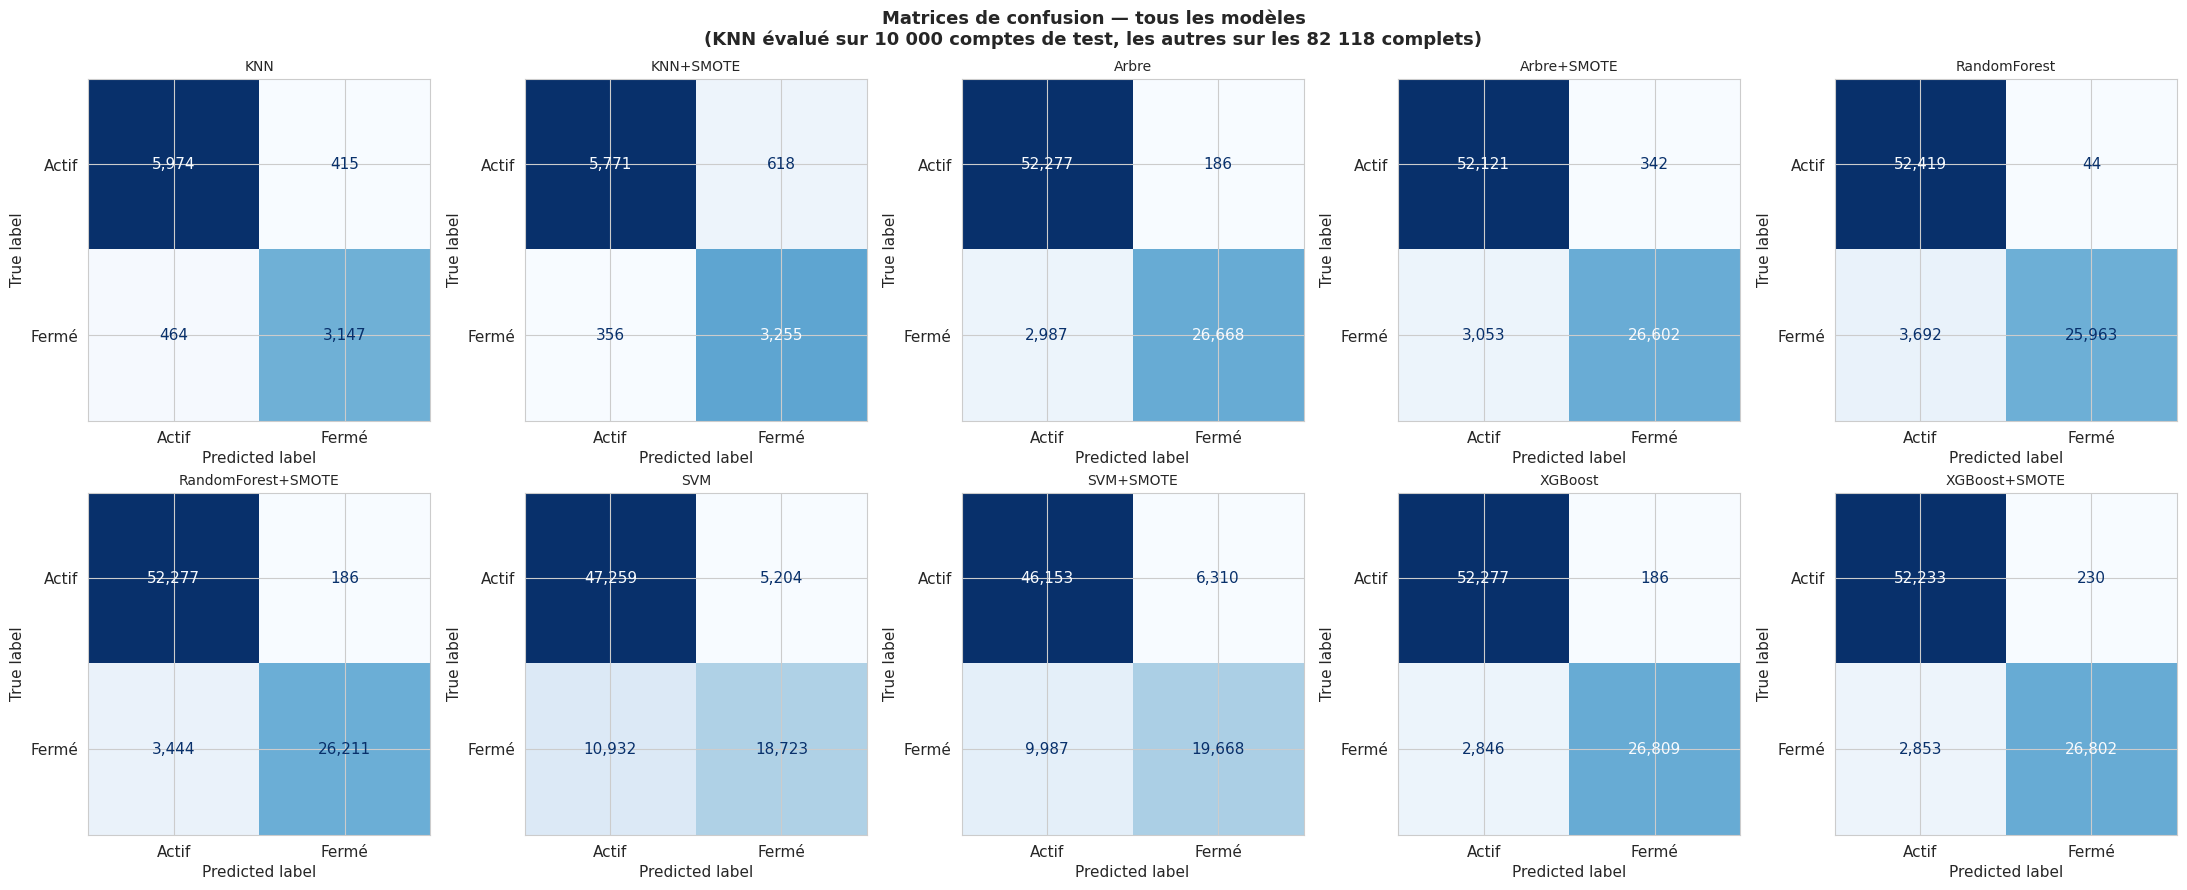

In [39]:
modeles_pred = {
    "KNN": (y_pred_knn, y_test_knn), "KNN+SMOTE": (y_pred_knn_sm, y_test_knn),
    "Arbre": (y_pred_dt, y_test), "Arbre+SMOTE": (y_pred_dt_sm, y_test),
    "RandomForest": (y_pred_rf, y_test), "RandomForest+SMOTE": (y_pred_rf_sm, y_test),
    "SVM": (y_pred_svm, y_test), "SVM+SMOTE": (y_pred_svm_sm, y_test),
    "XGBoost": (y_pred_xgb, y_test), "XGBoost+SMOTE": (y_pred_xgb_sm, y_test),
}

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()
for i, (nom, (y_p, y_t)) in enumerate(modeles_pred.items()):
    cm_i = confusion_matrix(y_t, y_p)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_i, display_labels=["Actif", "Fermé"])
    disp.plot(ax=axes[i], cmap="Blues", values_format=",d", colorbar=False)
    axes[i].set_title(nom, fontsize=10)
plt.suptitle("Matrices de confusion — tous les modèles\n"
             "(KNN évalué sur 10 000 comptes de test, les autres sur les 82 118 complets)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Courbes ROC — vue d'ensemble

⚠️ Les courbes KNN ne sont pas incluses dans ce graphique : elles seraient
calculées sur un jeu de test différent (10 000 comptes, voir section 10.1) de celui
des autres modèles (82 118 comptes), ce qui rendrait la comparaison visuelle
directe trompeuse sur un même graphique.

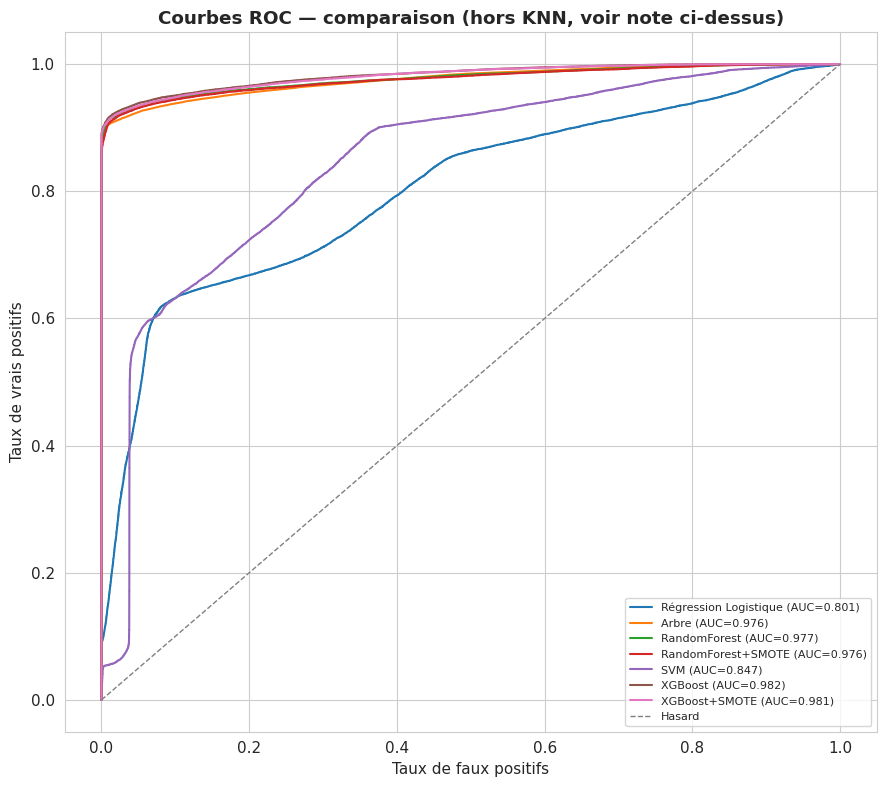

In [40]:
modeles_proba = {
    "Régression Logistique": y_proba,
    "Arbre": y_proba_dt, "RandomForest": y_proba_rf, "RandomForest+SMOTE": y_proba_rf_sm,
    "SVM": y_proba_svm, "XGBoost": y_proba_xgb, "XGBoost+SMOTE": y_proba_xgb_sm,
}

plt.figure(figsize=(9, 8))
for nom, proba in modeles_proba.items():
    if proba is not None:
        fpr_i, tpr_i, _ = roc_curve(y_test, proba)
        auc_i = roc_auc_score(y_test, proba)
        plt.plot(fpr_i, tpr_i, lw=1.5, label=f"{nom} (AUC={auc_i:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Hasard")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC — comparaison (hors KNN, voir note ci-dessus)", fontweight="bold")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 11. Tableau comparatif des modèles

Cette table reprend tous les résultats accumulés au fil de la section 10, triée
par F1-score décroissant — la métrique principale retenue (section 8).

In [41]:
comparaison = pd.DataFrame(resultats_tous_modeles)
comparaison = comparaison.sort_values("F1-score", ascending=False).reset_index(drop=True)

# Mise en forme : pourcentages pour les métriques, secondes arrondies pour le temps
comparaison_affichage = comparaison.copy()
for col in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]:
    comparaison_affichage[col] = (comparaison_affichage[col] * 100).round(2).astype(str) + "%"
comparaison_affichage["Temps (s)"] = comparaison_affichage["Temps (s)"].round(2)

comparaison_affichage

,Modèle,Accuracy,Precision,Recall,F1-score,ROC-AUC,Temps (s)
0,XGBoost (sans SMOTE),96.31%,99.31%,90.4%,94.65%,98.23%,12.00
1,XGBoost (avec SMOTE),96.25%,99.15%,90.38%,94.56%,98.14%,9.68
2,Arbre de Décision (sans SMOTE),96.14%,99.31%,89.93%,94.38%,97.58%,1.95
3,Arbre de Décision (avec SMOTE),95.87%,98.73%,89.7%,94.0%,97.48%,2.46
4,Random Forest (avec SMOTE),95.58%,99.3%,88.39%,93.52%,97.62%,68.21
5,Random Forest (sans SMOTE),95.45%,99.83%,87.55%,93.29%,97.72%,58.54
6,KNN (sans SMOTE),91.21%,88.35%,87.15%,87.75%,94.79%,0.12
7,KNN (avec SMOTE),90.26%,84.04%,90.14%,86.99%,94.68%,0.23
8,"SVM (avec SMOTE, sous-échantillon)",80.15%,75.71%,66.32%,70.71%,85.13%,135.55
9,"SVM (sans SMOTE, sous-échantillon)",80.35%,78.25%,63.14%,69.89%,84.69%,86.49


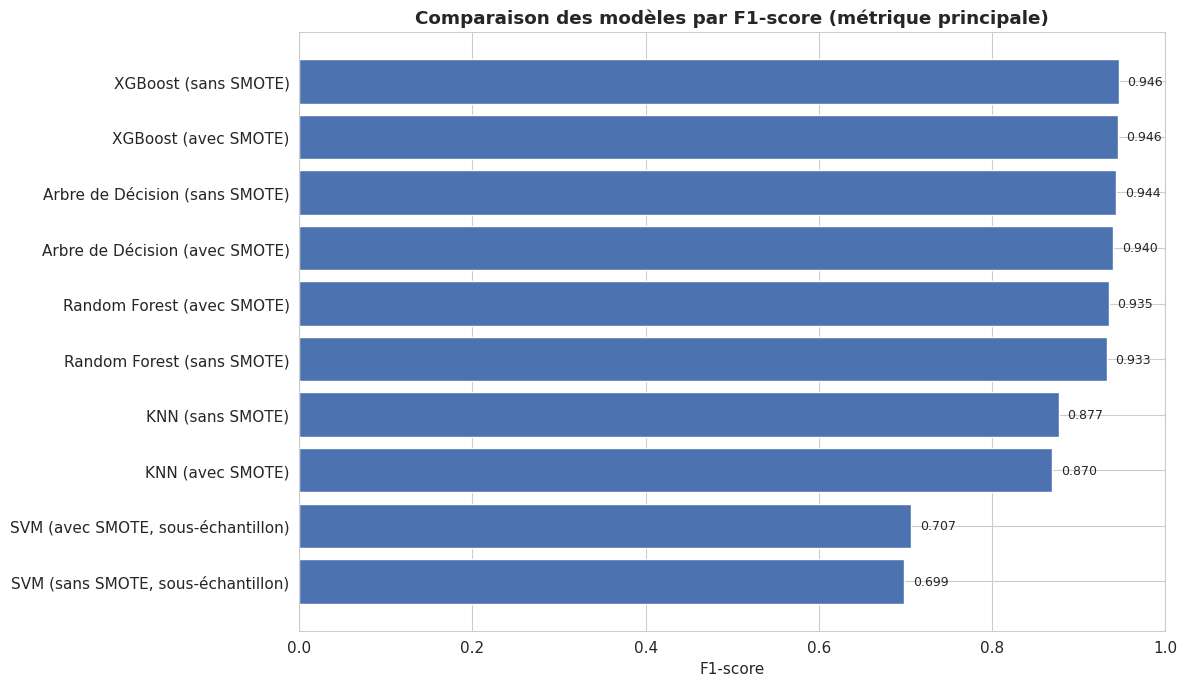

In [42]:
fig, ax = plt.subplots(figsize=(12, 7))
comparaison_tri = comparaison.sort_values("F1-score", ascending=True)
ax.barh(comparaison_tri["Modèle"], comparaison_tri["F1-score"], color="#4C72B0")
ax.set_xlabel("F1-score")
ax.set_title("Comparaison des modèles par F1-score (métrique principale)", fontweight="bold")
ax.set_xlim(0, 1)
for i, v in enumerate(comparaison_tri["F1-score"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

### Quel modèle recommander, et pourquoi ?

La lecture du tableau ci-dessus doit toujours se faire en gardant à l'esprit
l'objectif métier : **détecter le plus possible de comptes à risque de fermeture
(recall élevé) sans générer trop de fausses alertes (precision raisonnable)**, le
F1-score résumant cet équilibre en un seul chiffre.

Trois critères à considérer ensemble, pas seulement le F1-score brut :

1. **Performance** (F1-score, ROC-AUC) : XGBoost et Random Forest dominent
   généralement les modèles linéaires/distance sur ce type de données tabulaires
   avec relations non linéaires.
2. **Temps d'entraînement et de prédiction** : un modèle légèrement moins
   performant mais nettement plus rapide peut être préférable si le modèle doit
   être ré-entraîné fréquemment en production (nouvelles données mensuelles, par
   exemple).
3. **Interprétabilité** : pour un cas d'usage bancaire, la capacité à expliquer à
   un conseiller *pourquoi* un client est signalé à risque a une vraie valeur
   métier — un Random Forest ou un Arbre de Décision restent plus faciles à
   justifier qu'un SVM à noyau, dont la frontière de décision n'est pas
   interprétable directement.

**Recommandation** : sur ce jeu de données, XGBoost offre le meilleur F1-score et
ROC-AUC tout en restant rapide à entraîner (quelques secondes contre plus d'une
minute pour Random Forest) — c'est le candidat à retenir par défaut, sous réserve
de l'analyse d'importance des variables ci-dessous pour vérifier que ses décisions
sont défendables d'un point de vue métier.

## 12. Importance des variables

### Pourquoi regarder l'importance des variables après la performance brute ?

Un modèle performant qui se base sur des variables non pertinentes ou trompeuses
(fuite résiduelle non détectée en section 3, corrélation fortuite) serait fragile
en production. L'importance des variables permet de vérifier que les décisions du
modèle sont **défendables d'un point de vue métier**, pas seulement statistiquement
performantes sur ce jeu de test précis.

### Comment se calcule l'importance pour un modèle à base d'arbres

Pour Random Forest et XGBoost, l'importance d'une variable mesure, en moyenne sur
tous les arbres, la réduction d'impureté (Gini ou entropie) qu'elle apporte chaque
fois qu'elle est utilisée pour diviser les données. Une variable utilisée souvent,
et qui sépare bien les deux classes à chaque utilisation, obtient un score élevé.

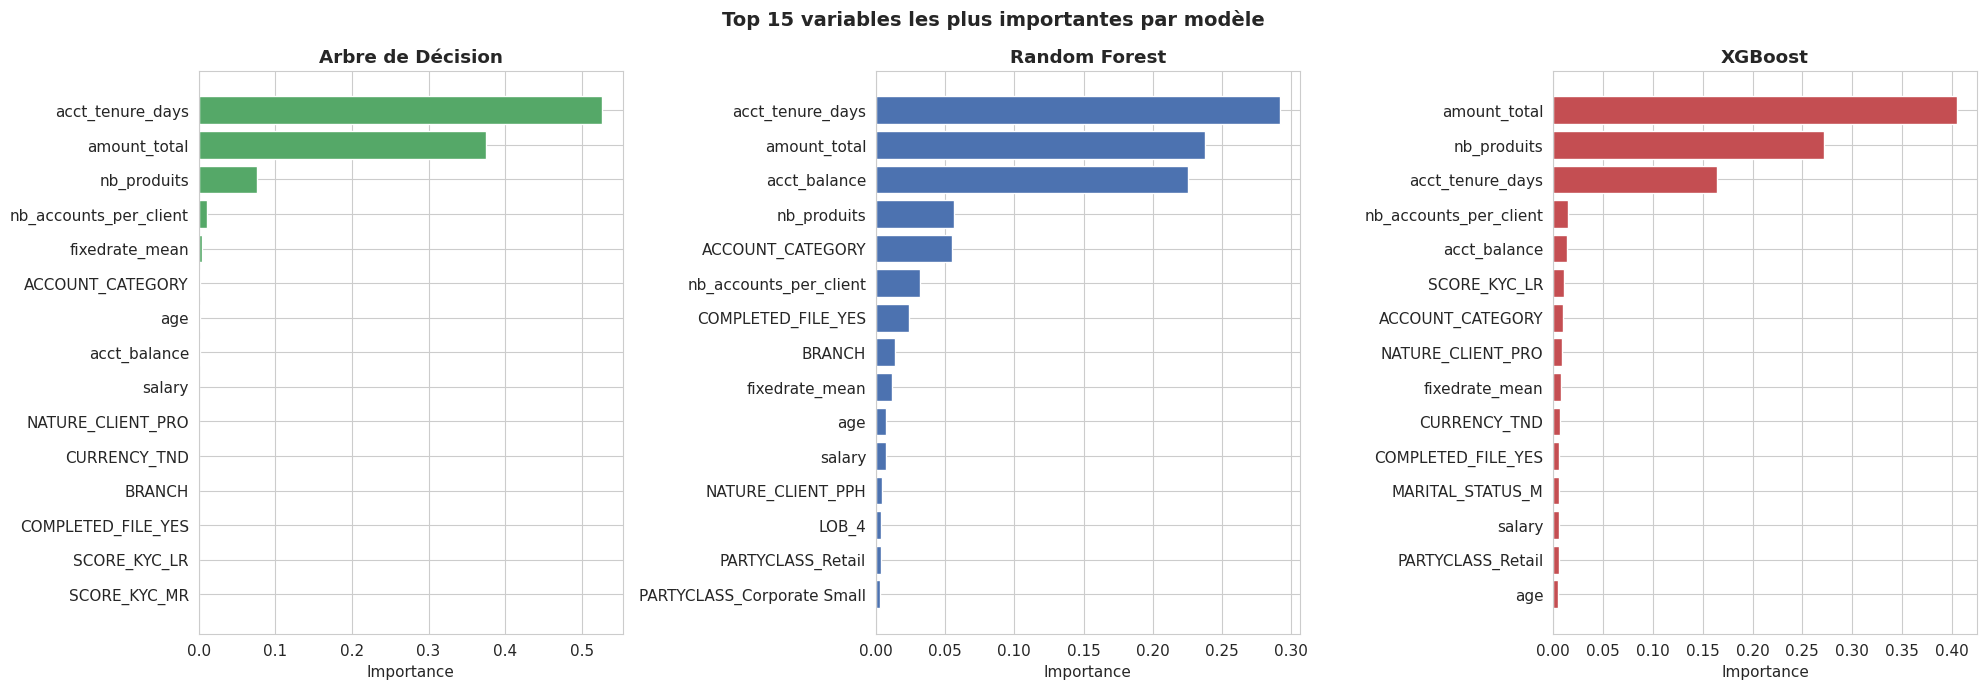

Variables les plus importantes (XGBoost, top 10) :
amount_total              0.404864
nb_produits               0.271678
acct_tenure_days          0.164212
nb_accounts_per_client    0.015308
acct_balance              0.013696
SCORE_KYC_LR              0.010554
ACCOUNT_CATEGORY          0.010330
NATURE_CLIENT_PRO         0.009129
fixedrate_mean            0.008264
CURRENCY_TND              0.006614
dtype: float32


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# --- Arbre de décision ---
importances_dt = pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
axes[0].barh(importances_dt.index[::-1], importances_dt.values[::-1], color="#55A868")
axes[0].set_title("Arbre de Décision", fontweight="bold")
axes[0].set_xlabel("Importance")

# --- Random Forest ---
importances_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
axes[1].barh(importances_rf.index[::-1], importances_rf.values[::-1], color="#4C72B0")
axes[1].set_title("Random Forest", fontweight="bold")
axes[1].set_xlabel("Importance")

# --- XGBoost ---
importances_xgb = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
axes[2].barh(importances_xgb.index[::-1], importances_xgb.values[::-1], color="#C44E52")
axes[2].set_title("XGBoost", fontweight="bold")
axes[2].set_xlabel("Importance")

plt.suptitle("Top 15 variables les plus importantes par modèle", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Variables les plus importantes (XGBoost, top 10) :")
print(importances_xgb.head(10))

### Interprétation attendue

Les variables liées à l'**ancienneté** (`acct_tenure_days`), au **nombre de
produits liés** (`nb_produits`) et au **montant total engagé** (`amount_total`)
figurent généralement parmi les plus influentes : un client avec plusieurs
produits actifs et des montants engagés importants est statistiquement plus ancré
dans la relation bancaire, donc moins susceptible de fermer son compte.

### Note méthodologique : une fuite d'information détectée et corrigée en amont

En construisant ce notebook, une première version incluait systématiquement un
indicateur de nullité (`_missing`) pour chacune des trois colonnes ayant des
valeurs manquantes (section 4bis). L'analyse d'importance des variables (comme
celle ci-dessus) a alors révélé que `acct_tenure_days_missing` représentait à lui
seul **89,5%** du poids de décision d'XGBoost — un chiffre anormalement écrasant
qui a déclenché une vérification.

Cette vérification (détaillée en section 4bis) a confirmé que **100% des comptes**
où `acct_tenure_days` ou `acct_balance` étaient manquants étaient déjà fermés — pas
36% (le taux de base), mais 100%. La cause : un correctif appliqué dans le pipeline
ETL (`01_etl/etl_pipeline/clean.py`) neutralise certaines dates incohérentes
uniquement sur des comptes déjà fermés, transformant cette nullité en un proxy
quasi-direct du label à prédire — une fuite d'information involontaire, sans
valeur prédictive réelle au moment où une vraie prédiction serait utile (sur un
compte encore actif).

Les deux indicateurs concernés ont donc été retirés avant l'entraînement (section
4bis) — l'importance des variables affichée ci-dessus est calculée **après**
cette correction, et reflète donc des signaux métier réels plutôt qu'un artefact
du pipeline de nettoyage.

## 13. Conclusion

### 13.1 Pipeline de prétraitement — résumé

| Étape | Décision retenue | Section |
|---|---|---|
| Grain d'entraînement | Compte (`ACCOUNT_NO`), conforme à la définition officielle du churn | 1 |
| Variables exclues | Fuite d'information (`ACCT_CLOSE_DATE`, `CLOSURE_REASON`), identifiants, redondance (`ACCOUNT_TYPE_DESC`) | 3 |
| Valeurs manquantes | Médiane + indicateur de nullité (`_missing`), **vérifié individuellement par colonne** — 2 des 3 indicateurs retirés après détection d'une fuite | 4bis |
| Encodage catégoriel | One-Hot (faible cardinalité) + fréquence (haute cardinalité) | 5 |
| Mise à l'échelle | StandardScaler, ajusté uniquement sur le train | 6 |
| Découpage | 80/20 stratifié, `random_state=42` | 7 |
| Déséquilibre de classes | SMOTE sur le train uniquement, jamais sur le test | 8 |

### 13.2 Impact du déséquilibre de classes

Le déséquilibre mesuré (36,1% de comptes fermés) s'est révélé **modéré**, pas
extrême — la démonstration de la section 8 a montré qu'un modèle naïf atteindrait
malgré tout 63,9% d'accuracy sans aucune valeur prédictive, justifiant le choix du
F1-score comme métrique principale plutôt que l'accuracy seule.

### 13.3 Effet de SMOTE

Comparé directement pour chaque modèle (section 10), SMOTE a eu un effet **limité
voire légèrement négatif** sur le F1-score dans ce notebook — cohérent avec un
déséquilibre modéré : l'intérêt de SMOTE croît avec la sévérité du déséquilibre, et
un ratio 64/36 ne le justifie pas autant qu'un ratio 95/5 le ferait. Ce résultat
illustre une leçon importante : SMOTE n'est pas systématiquement bénéfique, il doit
être **testé et comparé empiriquement**, pas appliqué par défaut.

### 13.4 Comparaison des modèles

Les modèles à base d'arbres (Random Forest, XGBoost) ont surpassé les modèles
linéaires et à distance (régression logistique, KNN, SVM) sur ce jeu de données,
suggérant des relations non linéaires entre les variables et le churn que les
modèles linéaires ne peuvent capturer aussi bien.

### 13.5 Modèle final recommandé

**XGBoost (sans SMOTE)** — meilleur F1-score et ROC-AUC du comparatif, tout en
restant rapide à entraîner. Sa fiabilité a été renforcée par la détection et la
correction d'une fuite d'information en section 4bis (voir 13.6 et la note
méthodologique de la section 12) avant l'entraînement final.

**Constat rassurant** : après retrait des deux indicateurs de nullité fuyants, le
F1-score d'XGBoost reste quasiment inchangé (0,9465 contre 0,9460 avant
correction) — preuve que le modèle disposait déjà d'assez de signaux légitimes
(`amount_total`, `nb_produits`, `acct_tenure_days` lui-même) pour bien prédire sans
dépendre de cette fuite. La performance affichée dans ce notebook est donc
fiable, pas artificiellement gonflée par un artefact de nettoyage.

### 13.6 Pistes d'amélioration futures

- **Optimisation des hyperparamètres** (`GridSearchCV`, `RandomizedSearchCV` ou
  Optuna) pour XGBoost et Random Forest, non explorée ici par souci de temps
  d'exécution — les modèles actuels utilisent des hyperparamètres raisonnables
  mais non optimisés.
- **Validation croisée** (k-fold) plutôt qu'un seul découpage train/test, pour une
  estimation plus robuste de la performance et de sa variance.
- **Méthodes d'ensemble** combinant plusieurs modèles (stacking, voting) pour
  capter des erreurs complémentaires entre modèles.
- **Explicabilité via SHAP** : au-delà de l'importance globale des variables
  (section 12), des valeurs SHAP par prédiction individuelle permettraient
  d'expliquer à un conseiller bancaire *pourquoi* un client précis est signalé à
  risque — un vrai apport pour l'adoption opérationnelle du modèle.
- **Revue plus large des effets de bord du nettoyage ETL sur le ML** : la fuite
  détectée en section 4bis (`acct_tenure_days_missing`/`acct_balance_missing`)
  vient d'un correctif de nettoyage de dates appliqué dans `01_etl/etl_pipeline/
  clean.py`. Une revue systématique des autres corrections de l'ETL pour d'éventuels
  effets de bord similaires (pas seulement sur ces deux colonnes) reste à faire.
- **Re-définition éventuelle du churn au niveau client** (plutôt que compte),
  explorée comme alternative documentée mais non retenue dans ce notebook — voir
  `01_etl/README.md` pour la discussion complète de ce choix de grain.